# Book Commercial Success — Data Pipeline & EDA

**Datasets:**
- GoodBooks-10k Extended (base table — features)
- NYT Hardcover Fiction Bestsellers 1931–2020 — Post45 (target labels)

**Pipeline overview:**
1. Load both datasets
2. Inspect & understand structure
3. Clean each dataset individually
4. Build standardized ISBN keys and run exact ISBN matching
5. Fuzzy title + author matching for unmatched rows
6. Assign final labels and quality checks
7. Exploratory Data Analysis (EDA)

## 0. Install & Import

In [95]:
# Run this cell once to install required packages
# !pip install thefuzz python-Levenshtein pandas numpy matplotlib seaborn

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
try:
    from thefuzz import fuzz
except ImportError:
    fuzz = None
    print('Optional package `thefuzz` is not installed. Exact ISBN matching will still work; install it before fuzzy matching.')
import re
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

print('All packages imported successfully.')

All packages imported successfully.


---
## 1. Load Datasets

**Post45 note:** The Post45 dataset comes as two files:
- `nyt_hardcover_fiction_bestsellers-lists.csv` — weekly entries (one row per book per week)
- `nyt_hardcover_fiction_bestsellers-titles.csv` — already aggregated (one row per unique title)

We use the **titles file** directly — it already has `total_weeks` and `best_rank` pre-computed for us.

In [53]:
# ── GoodBooks-10k Extended ──────────────────────────────────────────────────
# The genres column is stored as a Python list string, so we use literal_eval
# to convert it back to an actual list on load.
GOODBOOKS_URL = (
    'https://raw.githubusercontent.com/malcolmosh/goodbooks-10k-extended/'
    'master/books_enriched.csv'
)

books = pd.read_csv(
    GOODBOOKS_URL,
    index_col=0,
    converters={'genres': literal_eval}  # parse genres from string to list
)

print(f'GoodBooks loaded: {books.shape[0]:,} rows × {books.shape[1]} columns')
books.head(3)

GoodBooks loaded: 10,000 rows × 29 columns


,index,authors,average_rating,best_book_id,book_id,books_count,description,genres,goodreads_book_id,image_url,isbn,isbn13,language_code,original_publication_year,original_title,pages,publishDate,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,ratings_count,small_image_url,title,work_id,work_ratings_count,work_text_reviews_count,authors_2
0,0,['Suzanne Collins'],4.34,2767052,1,272,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES HAVE BEGUN. . . .In the ruins of a place ...,"[young-adult, fiction, fantasy, science-fiction, romance]",2767052,https://images.gr-assets.com/books/1447303603m/2767052.jpg,439023483,9.780439e+12,eng,2008.0,The Hunger Games,374.0,09/14/08,66715,127936,560092,1481305,2706317,4780653,https://images.gr-assets.com/books/1447303603s/2767052.jpg,"The Hunger Games (The Hunger Games, #1)",2792775,4942365,155254,['Suzanne Collins']
1,1,"['J.K. Rowling', 'Mary GrandPré']",4.44,3,2,491,"Harry Potter's life is miserable. His parents are dead and he's stuck with his heartless relatives, who force him to...","[fantasy, fiction, young-adult, classics]",3,https://images.gr-assets.com/books/1474154022m/3.jpg,439554934,9.780440e+12,eng,1997.0,Harry Potter and the Philosopher's Stone,309.0,11/01/03,75504,101676,455024,1156318,3011543,4602479,https://images.gr-assets.com/books/1474154022s/3.jpg,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",4640799,4800065,75867,"['J.K. Rowling', 'Mary GrandPré']"
2,2,['Stephenie Meyer'],3.57,41865,3,226,"About three things I was absolutely positive.\n\nFirst, Edward was a vampire.\n\nSecond, there was a part of him—and...","[young-adult, fantasy, romance, fiction, paranormal]",41865,https://images.gr-assets.com/books/1361039443m/41865.jpg,316015849,9.780316e+12,eng,2005.0,Twilight,501.0,09/06/06,456191,436802,793319,875073,1355439,3866839,https://images.gr-assets.com/books/1361039443s/41865.jpg,"Twilight (Twilight, #1)",3212258,3916824,95009,['Stephenie Meyer']


In [54]:
# ── Post45 NYT — Unique Titles file (already one row per title) ─────────────
NYT_TITLES_URL = (
    'https://raw.githubusercontent.com/Post45-Data-Collective/data/refs/heads/main/'
    'nyt_hardcover_fiction_bestsellers/nyt_hardcover_fiction_bestsellers-titles.csv'
)

nyt = pd.read_csv(NYT_TITLES_URL)

print(f'Post45 NYT titles loaded: {nyt.shape[0]:,} rows × {nyt.shape[1]} columns')
nyt.head(3)
nyt

Post45 NYT titles loaded: 7,431 rows × 17 columns


,id,author,author_authorized_heading,author_lccn,author_viaf,author_wikidata,best_rank,debut_rank,first_week,oclc,oclc_eholdings,oclc_holdings,oclc_isbn,oclc_owi,title,total_weeks,year
0,0,Sue Grafton,"Grafton, Sue",n81098191,113386374,Q234865,2,15,1991-05-05,2.281275e+07,194.0,5057.0,080501084X,5.465260e+05,"""H"" IS FOR HOMICIDE",15,1991
1,1,Sue Grafton,"Grafton, Sue",n81098191,113386374,Q234865,2,2,1992-04-26,2.500930e+07,163.0,5123.0,0805010858,3.547810e+05,"""I"" IS FOR INNOCENT",11,1992
2,10,Sue Grafton,"Grafton, Sue",n81098191,113386374,Q234865,8,8,1990-05-06,2.056078e+07,181.0,5071.0,0805004610,5.465240e+05,''G'' IS FOR GUMSHOE,6,1990
3,100,W. Bruce Cameron,"Cameron, Bruce W.,",n2001024987,47877397,Q7945367,14,14,2012-05-27,7.609748e+08,99.0,2444.0,9780765330536,1.661230e+09,A DOG'S JOURNEY,1,2012
4,1000,Kimberla Lawson Roby,"Roby, Kimberla Lawson",n97066944,46049281,Q20711059,14,14,2006-02-19,5.757379e+07,96.0,1265.0,0060780770,9.175864e+08,CHANGING FACES,1,2006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7426,995,Jackie Collins,"Collins, Jackie",n79113048,100253982,Q1837775,15,15,1981-10-04,7.205537e+06,81.0,1173.0,NaN,4.838540e+05,CHANCES,1,1981
7427,996,Richard Russo,"Russo, Richard, 1949-",n86089055,49329265,Q558430,8,8,2019-08-18,1.086485e+09,192.0,2496.0,NaN,8.936618e+09,CHANCES ARE ...,3,2019
7428,997,Jodi Picoult,"Picoult, Jodi, 1966-",n91118775,37821799,Q234443,1,1,2008-03-23,1.663731e+08,183.0,4873.0,NaN,1.128976e+08,CHANGE OF HEART,8,2008
7429,998,Danielle Steel,"Steel, Danielle",n80061569,100238676,Q72653,2,6,1983-09-11,9.371188e+06,287.0,2856.0,NaN,6.321990e+05,CHANGES,28,1983


---
## 2. Inspect Structure

Before cleaning anything, understand the structure of each dataset

In [55]:
# ── GoodBooks: column names, types, missing value counts ───────────────────
print('=== GoodBooks-10k Extended ===')
print(f'Shape: {books.shape}\n')

missing = books.isnull().sum()
missing_pct = (missing / len(books) * 100).round(2)
info_df = pd.DataFrame({
    'dtype': books.dtypes,
    'missing_count': missing,
    'missing_%': missing_pct
})
print(info_df)

=== GoodBooks-10k Extended ===
Shape: (10000, 29)

                             dtype  missing_count  missing_%
index                        int64              0       0.00
authors                        str              0       0.00
average_rating             float64              0       0.00
best_book_id                 int64              0       0.00
book_id                      int64              0       0.00
books_count                  int64              0       0.00
description                    str             57       0.57
genres                      object              0       0.00
goodreads_book_id            int64              0       0.00
image_url                      str              0       0.00
isbn                           str            700       7.00
isbn13                     float64            585       5.85
language_code                  str              0       0.00
original_publication_year  float64             21       0.21
original_title                 str

In [56]:
# ── Post45 NYT: column names, types, missing value counts ──────────────────
print('=== Post45 NYT Bestseller Titles ===')
print(f'Shape: {nyt.shape}\n')

missing_nyt = nyt.isnull().sum()
missing_nyt_pct = (missing_nyt / len(nyt) * 100).round(2)
info_nyt_df = pd.DataFrame({
    'dtype': nyt.dtypes,
    'missing_count': missing_nyt,
    'missing_%': missing_nyt_pct
})
print(info_nyt_df)

=== Post45 NYT Bestseller Titles ===
Shape: (7431, 17)

                             dtype  missing_count  missing_%
id                           int64              0       0.00
author                         str              1       0.01
author_authorized_heading      str            657       8.84
author_lccn                    str            672       9.04
author_viaf                 object            657       8.84
author_wikidata                str            900      12.11
best_rank                    int64              0       0.00
debut_rank                   int64              0       0.00
first_week                     str              0       0.00
oclc                       float64            601       8.09
oclc_eholdings             float64            601       8.09
oclc_holdings              float64            601       8.09
oclc_isbn                      str           3078      41.42
oclc_owi                   float64            601       8.09
title                        

In [57]:
# Quick look at a few rows of the NYT titles dataset
# Key columns we care about: title, author, total_weeks, best_rank, oclc_isbn
nyt[['title', 'author', 'year', 'total_weeks', 'best_rank', 'debut_rank', 'oclc_isbn']].head(10)

,title,author,year,total_weeks,best_rank,debut_rank,oclc_isbn
0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,2,15,080501084X
1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,2,2,0805010858
2,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,8,8,0805004610
3,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,14,14,9780765330536
4,CHANGING FACES,Kimberla Lawson Roby,2006,1,14,14,0060780770
5,CHAOS,Patricia Cornwell,2016,3,7,7,9780062436689
6,CHAPTERHOUSE: DUNE,Frank Herbert,1985,16,2,14,0399130276
7,CHARADE,Sandra Brown,1994,5,10,12,0446516562
8,CHARLESTON,John Jakes,2002,4,12,12,0525946500
9,CHARLOTTE GRAY,Sebastian Faulks,1999,1,17,17,037550169X


In [58]:
# What does a description look like in GoodBooks?
print(books['description'].iloc[0])

WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES HAVE BEGUN. . . .In the ruins of a place once known as North America lies the nation of Panem, a shining Capitol surrounded by twelve outlying districts. The Capitol is harsh and cruel and keeps the districts in line by forcing them all to send one boy and once girl between the ages of twelve and eighteen to participate in the annual Hunger Games, a fight to the death on live TV.Sixteen-year-old Katniss Everdeen regards it as a death sentence when she steps forward to take her sister's place in the Games. But Katniss has been close to dead before—and survival, for her, is second nature. Without really meaning to, she becomes a contender. But if she is to win, she will have to start making choices that weight survival against humanity and life against love.


In [59]:
# What do genres look like? (should be a list)
print(books['genres'].iloc[:5].tolist())

[['young-adult', 'fiction', 'fantasy', 'science-fiction', 'romance'], ['fantasy', 'fiction', 'young-adult', 'classics'], ['young-adult', 'fantasy', 'romance', 'fiction', 'paranormal'], ['classics', 'fiction', 'historical-fiction', 'young-adult'], ['classics', 'fiction', 'historical-fiction', 'romance']]


---
## 3. Clean GoodBooks-10k Extended

**Goals:**
- Standardize column names
- Clean isbn13 join key
- Parse publication year into numeric
- Flag leakage-risk columns (don't delete yet)
- Handle missing values

In [60]:
books_clean = books.copy().reset_index(drop=True)

# ── 3a. Standardize column names and create stable book ID ─────────────────
books_clean.columns = books_clean.columns.str.lower().str.strip()

# gb_id is the permanent identifier for the GoodBooks baseline universe.
# We use this later to guarantee the merge never duplicates or drops books.
books_clean['gb_id'] = np.arange(len(books_clean))

assert books_clean['gb_id'].is_unique
print(f'GoodBooks baseline rows: {len(books_clean):,}')
print('Columns:', books_clean.columns.tolist())

GoodBooks baseline rows: 10,000
Columns: ['index', 'authors', 'average_rating', 'best_book_id', 'book_id', 'books_count', 'description', 'genres', 'goodreads_book_id', 'image_url', 'isbn', 'isbn13', 'language_code', 'original_publication_year', 'original_title', 'pages', 'publishdate', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'ratings_count', 'small_image_url', 'title', 'work_id', 'work_ratings_count', 'work_text_reviews_count', 'authors_2', 'gb_id']


In [61]:
# ── 3c. Parse publication year ──────────────────────────────────────────────
# original_publication_year can have floats/strings — coerce to int
books_clean['pub_year'] = pd.to_numeric(
    books_clean['original_publication_year'], errors='coerce'
).astype('Int64')  # Int64 supports NaN for integers

print('Publication year range:')
print(books_clean['pub_year'].describe())

# Flag suspicious years (future or very ancient — likely errors)
suspicious = books_clean[
    (books_clean['pub_year'] < 1000) | (books_clean['pub_year'] > 2024)
]
print(f'\nSuspicious years: {len(suspicious)} rows')
if len(suspicious) > 0:
    print(suspicious[['title', 'pub_year']].head(10))

Publication year range:
count         9979.0
mean     1981.987674
std       152.576665
min          -1750.0
25%           1990.0
50%           2004.0
75%           2011.0
max           2017.0
Name: pub_year, dtype: Float64

Suspicious years: 38 rows
                                    title  pub_year
71                            The Odyssey      -720
311                             The Iliad      -750
368                        The Art of War      -500
489                               Beowulf       975
722                          The Republic      -380
773   Oedipus Rex  (The Theban Plays, #1)      -430
1025                         Tao Te Ching      -300
1044                       Aesop's Fables      -560
1199                           The Aeneid       -17
1429      Antigone (The Theban Plays, #3)      -441


In [62]:
# ── 3d. Normalize title and author for fuzzy matching later ─────────────────
def normalize_text(s):
    """Lowercase, strip punctuation and extra whitespace."""
    if pd.isnull(s):
        return ''
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", '', s)   # remove punctuation
    s = re.sub(r'\s+', ' ', s)           # collapse whitespace
    return s

books_clean['title_norm'] = books_clean['title'].apply(normalize_text)
books_clean['author_norm'] = books_clean['authors'].apply(normalize_text)

print('Sample normalized titles:')
books_clean[['title', 'title_norm', 'author_norm']].head(5)

Sample normalized titles:


,title,title_norm,author_norm
0,"The Hunger Games (The Hunger Games, #1)",the hunger games the hunger games 1,suzanne collins
1,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",harry potter and the sorcerers stone harry potter 1,jk rowling mary grandpr
2,"Twilight (Twilight, #1)",twilight twilight 1,stephenie meyer
3,To Kill a Mockingbird,to kill a mockingbird,harper lee
4,The Great Gatsby,the great gatsby,f scott fitzgerald


In [63]:
# ── 3e. Flag leakage-risk columns ───────────────────────────────────────────
# These are post-publication outcomes — we keep them in the dataframe
# for reference but will EXCLUDE from model features later.
LEAKAGE_COLS = [
    'average_rating', 'ratings_count', 'work_ratings_count',
    'work_text_reviews_count', 'ratings_1', 'ratings_2',
    'ratings_3', 'ratings_4', 'ratings_5'
]

# Only flag columns that actually exist in this dataset
leakage_present = [c for c in LEAKAGE_COLS if c in books_clean.columns]
print(f'Leakage-risk columns present: {leakage_present}')

# Verify they're there but note they should not go into the model
print('\nSample leakage column values:')
books_clean[leakage_present].describe().round(2)

Leakage-risk columns present: ['average_rating', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']

Sample leakage column values:


,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4.00,54001.24,59687.32,2919.96,1345.04,3110.88,11475.89,19965.70,23789.81
std,0.25,157369.96,167803.79,6124.38,6635.63,9717.12,28546.45,51447.36,79768.89
min,2.47,2716.00,5510.00,3.00,11.00,30.00,323.00,750.00,754.00
25%,3.85,13568.75,15438.75,694.00,196.00,656.00,3112.00,5405.75,5334.00
50%,4.02,21155.50,23832.50,1402.00,391.00,1163.00,4894.00,8269.50,8836.00
75%,4.18,41053.50,45915.00,2744.25,885.00,2353.25,9287.00,16023.50,17304.50
max,4.82,4780653.00,4942365.00,155254.00,456191.00,436802.00,793319.00,1481305.00,3011543.00


In [64]:
# ── 3f. Summary of cleaned GoodBooks ───────────────────────────────────────
print('=== GoodBooks Clean Summary ===')
print(f'Total books: {len(books_clean):,}')
# print(f'With valid isbn13: {books_clean["isbn13_clean"].notna().sum():,}')
print(f'With description: {books_clean["description"].notna().sum():,}')
print(f'With genres: {books_clean["genres"].apply(lambda x: len(x) > 0).sum():,}')
print(f'With pages: {books_clean["pages"].notna().sum():,}')
print(f'With pub_year: {books_clean["pub_year"].notna().sum():,}')

=== GoodBooks Clean Summary ===
Total books: 10,000
With description: 9,943
With genres: 10,000
With pages: 9,927
With pub_year: 9,979


---
## 4. Clean Post45 NYT Dataset

**Goals:**
- Use the **titles file** (already aggregated — one row per unique title)
- Clean oclc_isbn join key
- Normalize title/author for fuzzy matching
- Create `nyt_bestseller = 1` for all rows (by definition, every row here is a bestseller)

In [65]:
nyt_clean = nyt.copy()

# ── 4a. Standardize column names ────────────────────────────────────────────
nyt_clean.columns = nyt_clean.columns.str.lower().str.strip()
print('NYT columns:', nyt_clean.columns.tolist())

NYT columns: ['id', 'author', 'author_authorized_heading', 'author_lccn', 'author_viaf', 'author_wikidata', 'best_rank', 'debut_rank', 'first_week', 'oclc', 'oclc_eholdings', 'oclc_holdings', 'oclc_isbn', 'oclc_owi', 'title', 'total_weeks', 'year']


In [66]:
# ── 4c. Normalize title and author for fuzzy matching ───────────────────────
nyt_clean['title_norm'] = nyt_clean['title'].apply(normalize_text)
nyt_clean['author_norm'] = nyt_clean['author'].apply(normalize_text)

# ── 4d. Create target columns ───────────────────────────────────────────────
# Every row in the NYT titles file IS a bestseller by definition.
nyt_clean['nyt_bestseller'] = 1

# Rename for clarity.
nyt_clean = nyt_clean.rename(columns={
    'total_weeks': 'weeks_on_list',
    'best_rank': 'best_rank_achieved',
    'year': 'nyt_first_year'
})

# Coerce outcome/rank columns to numeric so sorting and summaries behave correctly.
for col in ['weeks_on_list', 'best_rank_achieved', 'nyt_first_year', 'debut_rank']:
    if col in nyt_clean.columns:
        nyt_clean[col] = pd.to_numeric(nyt_clean[col], errors='coerce')

print('NYT target columns created.')
print('weeks_on_list range:', nyt_clean['weeks_on_list'].min(),
      '–', nyt_clean['weeks_on_list'].max())
print('best_rank_achieved range:', nyt_clean['best_rank_achieved'].min(),
      '–', nyt_clean['best_rank_achieved'].max())

NYT target columns created.
weeks_on_list range: 1 – 178
best_rank_achieved range: 1 – 17


In [67]:
# ── 4e. Summary of cleaned NYT ──────────────────────────────────────────────
print('=== Post45 NYT Clean Summary ===')
print(f'Total unique bestselling title rows: {len(nyt_clean):,}')
# print(f'With valid ISBN key: {nyt_clean["oclc_isbn_clean"].notna().sum():,}')
# print(f'Unique valid ISBN keys: {nyt_clean["oclc_isbn_clean"].nunique():,}')
print(f'Year range: {nyt_clean["nyt_first_year"].min()} – {nyt_clean["nyt_first_year"].max()}')
print(f'Rows with normalized title + author: {((nyt_clean["title_norm"] != "") & (nyt_clean["author_norm"] != "")).sum():,}')
print(f'Potential duplicate title-author rows: {nyt_clean.duplicated(["title_norm", "author_norm"]).sum():,}')
print(f'\nTop 10 longest-running bestsellers:')
nyt_clean.nlargest(10, 'weeks_on_list')[['title', 'author', 'nyt_first_year', 'weeks_on_list', 'best_rank_achieved']]

=== Post45 NYT Clean Summary ===
Total unique bestselling title rows: 7,431
Year range: 1931 – 2020
Rows with normalized title + author: 7,430
Potential duplicate title-author rows: 59

Top 10 longest-running bestsellers:


,title,author,nyt_first_year,weeks_on_list,best_rank_achieved
2606,"OH, THE PLACES YOU'LL GO!",Dr. Seuss,1990,178,1
4219,THE CELESTINE PROPHECY,James Redfield,1994,165,1
4355,THE DA VINCI CODE,Dan Brown,2003,165,1
4139,THE BRIDGES OF MADISON COUNTY,Robert James Waller,1992,164,1
3124,ALL THE LIGHT WE CANNOT SEE,Anthony Doerr,2014,132,1
4167,THE CAINE MUTINY,Herman Wouk,1951,123,1
6934,WHERE THE CRAWDADS SING,Delia Owens,2018,114,1
4990,AUNTIE MAME,Patrick Dennis,1955,112,1
5732,THE ROBE,Lloyd C. Douglas,1942,111,1
4870,THE HELP,Kathryn Stockett,2009,108,1


---
## 5. ISBN Key Construction, Exact ISBN Merge, and Fuzzy Merge

**Goal:** keep **GoodBooks-10k Extended** as the fixed baseline universe.

**Matching strategy (3 passes in order of reliability):**
1. **Exact ISBN match** — fastest, zero ambiguity. Uses the validated `isbn13_key` built in 5b/5c.
2. **Fuzzy title + author match** — runs only on rows still unmatched after ISBN pass. Uses `thefuzz` with a weighted title/author score.
3. **Default to 0** — any book unmatched after both passes is coded as non-bestseller.

**Why this order matters:** ISBN matching is deterministic and produces no false positives. Fuzzy matching is probabilistic and must run *before* labels are finalized so that the `fillna(0)` step correctly reflects true non-matches rather than books the fuzzy pass could have caught.

**Why this section rebuilds ISBN keys:** raw ISBN fields are messy. GoodBooks `isbn` is mostly ISBN-10 but often lost leading zeros; GoodBooks `isbn13` sometimes looks like ISBN-13 but often fails the ISBN-13 check-digit test; NYT `oclc_isbn` mixes ISBN-10, ISBN-13, ISBN-10 values ending in `X`, and occasional suffix text such as `: HRD`.

**Strategy:**
1. Treat ISBNs as strings, not numbers.
2. For GoodBooks, use `isbn` first: left-pad to ISBN-10, validate, then convert to ISBN-13.
3. Use GoodBooks `isbn13` only as a fallback if it passes ISBN-13 validation.
4. For NYT, extract the ISBN-like part from `oclc_isbn`, validate it, and convert all valid ISBN-10 values to ISBN-13.
5. Merge NYT labels onto GoodBooks using a standardized `isbn13_key`.

Link: https://www.isbn-international.org/content/what-isbn/10?

In [68]:
# ── 5a. ISBN validation and conversion helper functions ─────────────────────
# These functions intentionally rebuild ISBN keys from the raw fields instead of
# relying on the earlier preliminary isbn13_clean column.

import re


def _as_clean_string(x):
    """
    Convert a raw ISBN-like value to a clean string while handling missing values
    and trailing .0 from float parsing.
    """
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()

    if s.lower() in {'', 'nan', 'none', 'null', 'na', 'n/a', '<na>'}:
        return pd.NA

    # Example: '9780439023480.0' -> '9780439023480'
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]

    return s


def isbn10_check_digit(first9: str) -> str:
    """Calculate the ISBN-10 check digit from the first 9 digits."""
    total = sum((10 - i) * int(d) for i, d in enumerate(first9))
    check_value = (11 - (total % 11)) % 11
    return 'X' if check_value == 10 else str(check_value)


def is_valid_isbn10(x) -> bool:
    """
    Validate a full 10-character ISBN-10.
    ISBN-10 can end in 0-9 or X.
    """
    s = _as_clean_string(x)
    if pd.isna(s):
        return False

    s = re.sub(r'[^0-9Xx]', '', s).upper()

    if len(s) != 10:
        return False
    if not s[:9].isdigit():
        return False
    if not (s[-1].isdigit() or s[-1] == 'X'):
        return False

    return isbn10_check_digit(s[:9]) == s[-1]


def isbn13_check_digit(first12: str) -> str:
    """
    Calculate the ISBN-13 check digit from the first 12 digits.
    ISBN-13 uses modulus 10 with alternating weights 1 and 3.
    """
    total = sum((1 if i % 2 == 0 else 3) * int(d)
                for i, d in enumerate(first12))
    return str((10 - (total % 10)) % 10)


def is_valid_isbn13(x) -> bool:
    """Validate a full 13-digit ISBN-13."""
    s = _as_clean_string(x)
    if pd.isna(s):
        return False

    s = re.sub(r'[^0-9]', '', s)

    if len(s) != 13:
        return False

    return isbn13_check_digit(s[:12]) == s[-1]


def clean_isbn10_with_left_padding(x):
    """
    Clean an ISBN-10-like value.

    Strategy:
    - Remove punctuation/spaces.
    - If shorter than 10 characters, left-pad with zeros.
    - Validate as ISBN-10.
    - Return clean ISBN-10 if valid; otherwise missing.
    """
    s = _as_clean_string(x)
    if pd.isna(s):
        return pd.NA

    s = re.sub(r'[^0-9Xx]', '', s).upper()

    if s == '':
        return pd.NA

    candidates = [s]
    if len(s) < 10:
        candidates.append(s.zfill(10))

    # Remove duplicate candidates while preserving order.
    for cand in dict.fromkeys(candidates):
        if is_valid_isbn10(cand):
            return cand

    return pd.NA


def convert_isbn10_to_isbn13(x):
    """Convert a valid ISBN-10 to ISBN-13."""
    s = _as_clean_string(x)
    if pd.isna(s):
        return pd.NA

    s = re.sub(r'[^0-9Xx]', '', s).upper()

    if not is_valid_isbn10(s):
        return pd.NA

    first12 = '978' + s[:9]
    return first12 + isbn13_check_digit(first12)


def clean_isbn13_direct(x):
    """
    Clean and validate a direct ISBN-13 value.
    Useful as a fallback for GoodBooks isbn13.
    """
    s = _as_clean_string(x)
    if pd.isna(s):
        return pd.NA

    s = re.sub(r'[^0-9]', '', s)

    if is_valid_isbn13(s):
        return s

    return pd.NA


In [69]:
# ── 5b. Build GoodBooks ISBN-13 key ───────────────────────────────────────

books_isbn = books_clean.copy()

# GoodBooks `isbn` is mostly ISBN-10, but leading zeros may be dropped.
books_isbn['isbn10_clean'] = books_isbn['isbn'].apply(clean_isbn10_with_left_padding)

# Convert cleaned ISBN-10 to ISBN-13.
books_isbn['isbn13_from_isbn10'] = books_isbn['isbn10_clean'].apply(convert_isbn10_to_isbn13)

# GoodBooks `isbn13` is used only as a fallback if it passes ISBN-13 validation.
books_isbn['isbn13_from_isbn13'] = books_isbn['isbn13'].apply(clean_isbn13_direct)

# Final recommended GoodBooks merge key.
books_isbn['isbn13_key'] = books_isbn['isbn13_from_isbn10'].combine_first(
    books_isbn['isbn13_from_isbn13']
)

# Stable GoodBooks row ID — this protects the 10,000-row baseline.
books_isbn = books_isbn.reset_index(drop=True).copy()
if 'gb_id' not in books_isbn.columns:
    books_isbn['gb_id'] = np.arange(len(books_isbn))

assert books_isbn['gb_id'].is_unique

print('=== GoodBooks ISBN diagnostics ===')
print(f'Rows: {len(books_isbn):,}')
print(f'Valid ISBN-10 values recovered from `isbn`: {books_isbn["isbn10_clean"].notna().sum():,}')
print(f'Valid ISBN-13 fallback values from `isbn13`: {books_isbn["isbn13_from_isbn13"].notna().sum():,}')
print(f'Usable final isbn13_key: {books_isbn["isbn13_key"].notna().sum():,}')
print(f'Unique final isbn13_key: {books_isbn["isbn13_key"].nunique():,}')
print(f'Duplicate final isbn13_key rows: {books_isbn.loc[books_isbn["isbn13_key"].notna(), "isbn13_key"].duplicated().sum():,}')

books_isbn[
    ['title', 'authors', 'isbn', 'isbn10_clean', 'isbn13',
     'isbn13_from_isbn10', 'isbn13_from_isbn13', 'isbn13_key']
].head(10)


=== GoodBooks ISBN diagnostics ===
Rows: 10,000
Valid ISBN-10 values recovered from `isbn`: 9,277
Valid ISBN-13 fallback values from `isbn13`: 957
Usable final isbn13_key: 9,293
Unique final isbn13_key: 9,293
Duplicate final isbn13_key rows: 0


,title,authors,isbn,isbn10_clean,isbn13,isbn13_from_isbn10,isbn13_from_isbn13,isbn13_key
0,"The Hunger Games (The Hunger Games, #1)",['Suzanne Collins'],439023483,0439023483,9.780439e+12,9780439023481,NaN,9780439023481
1,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","['J.K. Rowling', 'Mary GrandPré']",439554934,0439554934,9.780440e+12,9780439554930,9780439554930,9780439554930
2,"Twilight (Twilight, #1)",['Stephenie Meyer'],316015849,0316015849,9.780316e+12,9780316015844,NaN,9780316015844
3,To Kill a Mockingbird,['Harper Lee'],61120081,0061120081,9.780061e+12,9780061120084,NaN,9780061120084
4,The Great Gatsby,['F. Scott Fitzgerald'],743273567,0743273567,9.780743e+12,9780743273565,NaN,9780743273565
5,The Fault in Our Stars,['John Green'],525478817,0525478817,9.780525e+12,9780525478812,NaN,9780525478812
6,The Hobbit,['J.R.R. Tolkien'],618260307,0618260307,9.780618e+12,9780618260300,9780618260300,9780618260300
7,The Catcher in the Rye,['J.D. Salinger'],316769177,0316769177,9.780317e+12,9780316769174,NaN,9780316769174
8,"Angels & Demons (Robert Langdon, #1)",['Dan Brown'],1416524797,1416524797,9.781417e+12,9781416524793,NaN,9781416524793
9,Pride and Prejudice,['Jane Austen'],679783261,0679783261,9.780680e+12,9780679783268,NaN,9780679783268


In [70]:
# ── 5c. Build NYT ISBN-13 key from oclc_isbn ──────────────────────────────


def extract_isbn_candidates_from_oclc(x):
    """
    Extract possible ISBN candidates from NYT/OCLC field.

    Handles examples like:
    - '080501084X'
    - '9780765330536'
    - '0399167307 : HRD'
    - '0399167307 :'
    """
    s = _as_clean_string(x)
    if pd.isna(s):
        return []

    s = str(s).upper()

    # Remove spaces and hyphens, but keep colons/text so regex boundaries still work.
    compact = re.sub(r'[\s\-]', '', s)

    candidates = []

    # First extract ISBN-13 candidates.
    candidates += re.findall(r'97[89]\d{10}', compact)

    # Then extract ISBN-10-like candidates.
    # This allows shorter candidates too, because some may have lost leading zeros.
    candidates += re.findall(r'(?<!\d)\d{1,9}[\dX](?!\d)', compact)

    # Remove duplicates while preserving order.
    return list(dict.fromkeys(candidates))


def normalize_oclc_isbn_to_isbn13(x):
    """
    Normalize NYT oclc_isbn to ISBN-13.

    Strategy:
    - If candidate is valid ISBN-13, keep it.
    - Else if candidate is valid ISBN-10, convert to ISBN-13.
    - Else if candidate is short ISBN-10 with dropped leading zeros, left-pad,
      validate, and convert.
    """
    candidates = extract_isbn_candidates_from_oclc(x)

    for cand in candidates:
        # Direct valid ISBN-13.
        if re.fullmatch(r'\d{13}', cand) and is_valid_isbn13(cand):
            return cand

        # ISBN-10 or shortened ISBN-10.
        isbn10 = clean_isbn10_with_left_padding(cand)
        if pd.notna(isbn10):
            return convert_isbn10_to_isbn13(isbn10)

    return pd.NA


nyt_isbn = nyt_clean.copy()
nyt_isbn['isbn13_key'] = nyt_isbn['oclc_isbn'].apply(normalize_oclc_isbn_to_isbn13)

print('=== NYT ISBN diagnostics ===')
print(f'Rows: {len(nyt_isbn):,}')
print(f'Usable isbn13_key: {nyt_isbn["isbn13_key"].notna().sum():,}')
print(f'Unique isbn13_key: {nyt_isbn["isbn13_key"].nunique():,}')
print(f'Duplicate isbn13_key rows: {nyt_isbn.loc[nyt_isbn["isbn13_key"].notna(), "isbn13_key"].duplicated().sum():,}')

nyt_isbn[
    ['title', 'author', 'oclc_isbn', 'isbn13_key']
].head(10)


=== NYT ISBN diagnostics ===
Rows: 7,431
Usable isbn13_key: 4,353
Unique isbn13_key: 4,274
Duplicate isbn13_key rows: 79


,title,author,oclc_isbn,isbn13_key
0,"""H"" IS FOR HOMICIDE",Sue Grafton,080501084X,9780805010848
1,"""I"" IS FOR INNOCENT",Sue Grafton,0805010858,9780805010855
2,''G'' IS FOR GUMSHOE,Sue Grafton,0805004610,9780805004618
3,A DOG'S JOURNEY,W. Bruce Cameron,9780765330536,9780765330536
4,CHANGING FACES,Kimberla Lawson Roby,0060780770,9780060780777
5,CHAOS,Patricia Cornwell,9780062436689,9780062436689
6,CHAPTERHOUSE: DUNE,Frank Herbert,0399130276,9780399130274
7,CHARADE,Sandra Brown,0446516562,9780446516563
8,CHARLESTON,John Jakes,0525946500,9780525946502
9,CHARLOTTE GRAY,Sebastian Faulks,037550169X,9780375501692


In [71]:
# ── 5d. Check ISBN overlap before merging ─────────────────────────────────

gb_keys = set(books_isbn['isbn13_key'].dropna())
nyt_keys = set(nyt_isbn['isbn13_key'].dropna())
overlap = gb_keys.intersection(nyt_keys)

print('=== ISBN overlap ===')
print(f'GoodBooks usable ISBN-13 keys: {len(gb_keys):,}')
print(f'NYT usable ISBN-13 keys: {len(nyt_keys):,}')
print(f'Overlapping ISBN-13 keys: {len(overlap):,}')

# Inspect matched examples before merging.
overlap_examples = (
    books_isbn[books_isbn['isbn13_key'].isin(overlap)]
    [['title', 'authors', 'isbn', 'isbn10_clean', 'isbn13', 'isbn13_key']]
    .head(20)
)

overlap_examples


=== ISBN overlap ===
GoodBooks usable ISBN-13 keys: 9,293
NYT usable ISBN-13 keys: 4,274
Overlapping ISBN-13 keys: 676


,title,authors,isbn,isbn10_clean,isbn13,isbn13_key
13,"The Girl with the Dragon Tattoo (Millennium, #1)","['Stieg Larsson', 'Reg Keeland']",307269752,0307269752,9.780307e+12,9780307269751
19,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","['J.K. Rowling', 'Mary GrandPré']",439064864,0439064864,9.780439e+12,9780439064866
27,The Help,['Kathryn Stockett'],399155341,0399155341,9.780399e+12,9780399155345
54,The Girl on the Train,['Paula Hawkins'],1594633665,1594633665,9.781595e+12,9781594633669
60,A Thousand Splendid Suns,['Khaled Hosseini'],1594489505,1594489505,9.781594e+12,9781594489501
65,"The Host (The Host, #1)",['Stephenie Meyer'],316068047,0316068047,9.780316e+12,9780316068048
89,"The Girl Who Played with Fire (Millennium, #2)","['Stieg Larsson', 'Reg Keeland']",307269981,0307269981,9.780307e+12,9780307269980
95,The Road,['Cormac McCarthy'],307265439,0307265439,9.780307e+12,9780307265432
127,The Martian,['Andy Weir'],804139024,0804139024,9.780804e+12,9780804139021
129,All the Light We Cannot See,['Anthony Doerr'],1476746583,1476746583,9.781477e+12,9781476746586


In [72]:
# ── 5e. Deduplicate NYT on isbn13_key before exact merge ─────────────────

nyt_keyed = nyt_isbn[nyt_isbn['isbn13_key'].notna()].copy()

# Every row in the NYT titles file is a bestseller by construction.
nyt_keyed['nyt_bestseller'] = 1

# Harmonize column names in case the raw NYT data uses original names.
if 'total_weeks' in nyt_keyed.columns and 'weeks_on_list' not in nyt_keyed.columns:
    nyt_keyed['weeks_on_list'] = nyt_keyed['total_weeks']

if 'best_rank' in nyt_keyed.columns and 'best_rank_achieved' not in nyt_keyed.columns:
    nyt_keyed['best_rank_achieved'] = nyt_keyed['best_rank']

if 'year' in nyt_keyed.columns and 'nyt_first_year' not in nyt_keyed.columns:
    nyt_keyed['nyt_first_year'] = nyt_keyed['year']

# Keep useful NYT columns for exact ISBN merge.
nyt_keep_cols = [
    'isbn13_key',
    'title',
    'author',
    'title_norm',
    'author_norm',
    'nyt_bestseller',
    'weeks_on_list',
    'best_rank_achieved',
    'nyt_first_year',
    'debut_rank'
]
nyt_keep_cols = [c for c in nyt_keep_cols if c in nyt_keyed.columns]

nyt_for_exact = nyt_keyed[nyt_keep_cols].copy()

# Rename NYT fields to avoid confusion after the merge.
nyt_for_exact = nyt_for_exact.rename(columns={
    'title': 'nyt_title',
    'author': 'nyt_author',
    'title_norm': 'nyt_title_norm',
    'author_norm': 'nyt_author_norm'
})

# If duplicate ISBNs exist, keep the strongest bestseller record.
sort_cols = []
ascending = []

if 'weeks_on_list' in nyt_for_exact.columns:
    sort_cols.append('weeks_on_list')
    ascending.append(False)

if 'best_rank_achieved' in nyt_for_exact.columns:
    sort_cols.append('best_rank_achieved')
    ascending.append(True)

if sort_cols:
    nyt_for_exact = nyt_for_exact.sort_values(
        by=sort_cols,
        ascending=ascending,
        na_position='last'
    )

nyt_for_exact_dedup = (
    nyt_for_exact
    .drop_duplicates(subset=['isbn13_key'], keep='first')
    .copy()
)

assert nyt_for_exact_dedup['isbn13_key'].is_unique

print('=== NYT exact-merge table ===')
print(f'Rows before deduplication: {len(nyt_for_exact):,}')
print(f'Rows after deduplication: {len(nyt_for_exact_dedup):,}')
print(f'Duplicate ISBN keys removed: {len(nyt_for_exact) - len(nyt_for_exact_dedup):,}')


=== NYT exact-merge table ===
Rows before deduplication: 4,353
Rows after deduplication: 4,274
Duplicate ISBN keys removed: 79


In [73]:
# ── 5f. Exact ISBN merge: GoodBooks baseline + NYT labels ────────────────

EXPECTED_ROWS = len(books_isbn)
assert books_isbn['gb_id'].is_unique, 'gb_id must uniquely identify GoodBooks rows.'

isbn_merged = books_isbn.merge(
    nyt_for_exact_dedup,
    on='isbn13_key',
    how='left',
    validate='m:1',
    suffixes=('', '_nyt')
)

# Critical safety checks.
assert len(isbn_merged) == EXPECTED_ROWS, 'Row count changed during ISBN merge!'
assert isbn_merged['gb_id'].is_unique, 'GoodBooks rows duplicated during ISBN merge!'

isbn_merged['match_method'] = np.where(
    isbn_merged['nyt_bestseller'].notna(),
    'exact_isbn',
    'unmatched'
)

exact_hits = (isbn_merged['match_method'] == 'exact_isbn').sum()

print('=== Exact ISBN merge results ===')
print(f'GoodBooks rows before merge: {EXPECTED_ROWS:,}')
print(f'Rows after merge: {len(isbn_merged):,}')
print(f'Exact ISBN matches: {exact_hits:,}')
print(f'Still unmatched: {(isbn_merged["match_method"] == "unmatched").sum():,}')


=== Exact ISBN merge results ===
GoodBooks rows before merge: 10,000
Rows after merge: 10,000
Exact ISBN matches: 676
Still unmatched: 9,324


In [74]:
# ── 5g. Prepare for fuzzy pass — do NOT fill labels yet ─────────────────
# We copy isbn_merged but leave nyt_bestseller as NaN for unmatched rows.
# The fuzzy pass in 5h–5k will attempt to fill those NaNs before we finalize.

pre_fuzzy = isbn_merged.copy()

unmatched_before_fuzzy = (pre_fuzzy['nyt_bestseller'].isna()).sum()
print(f'Exact ISBN matches: {exact_hits:,}')
print(f'Still unmatched (will attempt fuzzy): {unmatched_before_fuzzy:,}')
print(f'Total rows (must stay {EXPECTED_ROWS:,}): {len(pre_fuzzy):,}')
assert len(pre_fuzzy) == EXPECTED_ROWS, 'Row count changed!'


Exact ISBN matches: 676
Still unmatched (will attempt fuzzy): 9,324
Total rows (must stay 10,000): 10,000


### 5h–5k. Fuzzy Title + Author Matching

Runs only on books that did not match via ISBN. Uses `thefuzz.token_sort_ratio` on normalized titles
(weighted 70%) and `thefuzz.partial_ratio` on normalized authors (weighted 30%).

**Threshold:** 85 by default. Raise to 88–90 for higher precision (fewer wrong matches);
lower to 80–82 for higher recall (more matches, more risk of false positives).

**Always review the spot-check output** in 5k before trusting fuzzy matches.

In [75]:
# ── 5h. Build the NYT reference table for fuzzy matching ─────────────────
# Only use NYT rows that were NOT already consumed by the exact ISBN pass.
# This avoids assigning the same NYT title to two different GoodBooks rows.

from thefuzz import fuzz

# ISBN-matched NYT titles (identified via their isbn13_key appearing in pre_fuzzy)
isbn_matched_keys = set(pre_fuzzy.loc[pre_fuzzy['nyt_bestseller'].notna(), 'isbn13_key'].dropna())

# NYT rows still available for fuzzy: those whose key was NOT already matched
nyt_for_fuzzy = nyt_isbn[
    ~nyt_isbn['isbn13_key'].isin(isbn_matched_keys)
].copy()

# Pre-compute arrays — much faster than row-by-row .iterrows() lookups
nyt_fuzzy_titles  = nyt_for_fuzzy['title_norm'].fillna('').values
nyt_fuzzy_authors = nyt_for_fuzzy['author_norm'].fillna('').values
nyt_fuzzy_index   = nyt_for_fuzzy.index.values

print(f'NYT rows available for fuzzy matching: {len(nyt_for_fuzzy):,}')
print(f'GoodBooks rows to attempt fuzzy on:    {(pre_fuzzy["nyt_bestseller"].isna()).sum():,}')


NYT rows available for fuzzy matching: 6,744
GoodBooks rows to attempt fuzzy on:    9,324


In [76]:
# ── 5i. Run fuzzy matching ───────────────────────────────────────────────
# Runtime: 
# The early-exit (title score < 65) cuts most comparisons short.

from tqdm.auto import tqdm

FUZZY_THRESHOLD = 85   # combined score threshold (0–100). Raise for more precision.
AUTHOR_FLOOR = 55   # independent minimum 

unmatched_df = pre_fuzzy[pre_fuzzy['nyt_bestseller'].isna()].copy()

fuzzy_results = []  # {gb_id, nyt_idx, fuzzy_score}

for _, row in tqdm(unmatched_df.iterrows(), total=len(unmatched_df), desc='Fuzzy matching'):
    btitle  = row['title_norm']
    bauthor = row['author_norm']

    if not btitle:   # skip books with no title to match on
        continue

    best_score    = 0.0
    best_nyt_idx  = None
    best_t_score, best_a_score = None, None

    for nyt_idx, ntitle, nauthor in zip(nyt_fuzzy_index, nyt_fuzzy_titles, nyt_fuzzy_authors):
        # Fast early exit — skip if titles share almost nothing
        t_score = fuzz.token_sort_ratio(btitle, ntitle)
        if t_score < 65:
            continue
        a_score  = fuzz.partial_ratio(bauthor, nauthor)
        
        if a_score < AUTHOR_FLOOR:      # NEW — reject weak author matches outright,
            continue                    # regardless of how good the title match is

        combined = 0.7 * t_score + 0.3 * a_score
        if combined > best_score:
            best_score   = combined
            best_nyt_idx = nyt_idx
            best_t_score = t_score      
            best_a_score = a_score      

    if best_score >= FUZZY_THRESHOLD and best_nyt_idx is not None:
        fuzzy_results.append({
            'gb_id':       row['gb_id'],
            'nyt_idx':     best_nyt_idx,
            'fuzzy_score': best_score,
            't_score':     best_t_score,   
            'a_score':     best_a_score               
        })

fuzzy_df = pd.DataFrame(fuzzy_results)
print(f'\nFuzzy matches found: {len(fuzzy_df):,} additional books labeled as bestsellers')


Fuzzy matching:   0%|          | 0/9324 [00:00<?, ?it/s]


Fuzzy matches found: 774 additional books labeled as bestsellers


In [77]:
fuzzy_df[['t_score','a_score','fuzzy_score']].describe()

,t_score,a_score,fuzzy_score
count,774.000000,774.000000,774.000000
mean,99.173127,98.817829,99.066537
std,3.611610,4.860181,2.884783
min,79.000000,55.000000,85.300000
25%,100.000000,100.000000,100.000000
50%,100.000000,100.000000,100.000000
75%,100.000000,100.000000,100.000000
max,100.000000,100.000000,100.000000


In [78]:
# ── 5j. Apply fuzzy labels to pre_fuzzy ──────────────────────────────────
# Patch the NYT label columns into pre_fuzzy for each fuzzy match.
# We look up the NYT row by nyt_idx and write values into the GoodBooks row
# identified by gb_id.

NYT_LABEL_COLS = [
    'nyt_bestseller', 'weeks_on_list', 'best_rank_achieved',
    'nyt_first_year', 'debut_rank', 'nyt_title', 'nyt_author',   
]

# Build a gb_id → row-index lookup for fast assignment
gb_id_to_idx = pre_fuzzy.reset_index().set_index('gb_id')['index'].to_dict()

fuzzy_hit_count = 0

if len(fuzzy_df) > 0:
    for _, frow in fuzzy_df.iterrows():
        gb_idx  = gb_id_to_idx.get(frow['gb_id'])
        nyt_row = nyt_for_fuzzy.loc[frow['nyt_idx']]

        if gb_idx is None:
            continue

        # Only patch if still unmatched (safety guard against double-assignment)
        if pd.isna(pre_fuzzy.at[gb_idx, 'nyt_bestseller']):
            pre_fuzzy.at[gb_idx, 'nyt_bestseller']    = 1
            pre_fuzzy.at[gb_idx, 'weeks_on_list']     = nyt_row.get('weeks_on_list',     pd.NA)
            pre_fuzzy.at[gb_idx, 'best_rank_achieved']= nyt_row.get('best_rank_achieved', pd.NA)
            pre_fuzzy.at[gb_idx, 'nyt_first_year']    = nyt_row.get('nyt_first_year',    pd.NA)
            pre_fuzzy.at[gb_idx, 'debut_rank']        = nyt_row.get('debut_rank',        pd.NA)
            pre_fuzzy.at[gb_idx, 'nyt_title']         = nyt_row.get('title',  pd.NA)
            pre_fuzzy.at[gb_idx, 'nyt_author']        = nyt_row.get('author', pd.NA)
            pre_fuzzy.at[gb_idx, 'match_method']      = 'fuzzy_title_author'
            fuzzy_hit_count += 1

print(f'Fuzzy labels applied: {fuzzy_hit_count:,}')
print(f'Still unmatched after fuzzy: {pre_fuzzy["nyt_bestseller"].isna().sum():,}')
assert len(pre_fuzzy) == EXPECTED_ROWS, 'Row count changed after fuzzy pass!'
assert pre_fuzzy['gb_id'].is_unique, 'gb_id duplicated after fuzzy pass!'


Fuzzy labels applied: 760
Still unmatched after fuzzy: 8,564


In [79]:
# ── 5k. Spot-check fuzzy matches 
# Look for obvious wrong matches (different books with similar titles).

if len(fuzzy_df) > 0:
    sample_size = min(25, len(fuzzy_df))
    sample = fuzzy_df.sample(sample_size, random_state=42)

    print(f'FUZZY MATCH SPOT-CHECK — reviewing {sample_size} random matches')
    print('='*72)

    for _, frow in sample.iterrows():
        gb_row  = pre_fuzzy[pre_fuzzy['gb_id'] == frow['gb_id']].iloc[0]
        nyt_row = nyt_for_fuzzy.loc[frow['nyt_idx']]

        gb_title  = str(gb_row.get('title',   ''))[:55]
        gb_author = str(gb_row.get('authors', ''))[:35]
        nyt_title  = str(nyt_row.get('title',  ''))[:55]
        nyt_author = str(nyt_row.get('author', ''))[:35]

        match_ok = '✓' if frow['fuzzy_score'] >= 90 else ('?' if frow['fuzzy_score'] >= 85 else '✗')
        print(f"  [{match_ok} {frow['fuzzy_score']:.1f}]")
        print(f"    GoodReads: '{gb_title}' by {gb_author}")
        print(f"    NYT:       '{nyt_title}' by {nyt_author}")
        print()
else:
    print('No fuzzy matches were found. Consider lowering FUZZY_THRESHOLD in cell 5i.')


FUZZY MATCH SPOT-CHECK — reviewing 25 random matches
  [✓ 100.0]
    GoodReads: 'The Postmistress' by ['Sarah Blake', 'Orlagh Cassidy']
    NYT:       'THE POSTMISTRESS' by Sarah Blake

  [✓ 93.0]
    GoodReads: 'Morning, Noon & Night' by ['Sidney Sheldon']
    NYT:       'MORNING, NOON, AND NIGHT' by Sidney Sheldon

  [✓ 96.4]
    GoodReads: 'Delta of Venus' by ['Anaïs Nin']
    NYT:       'DELTA OF VENUS' by Anais Nin

  [✓ 100.0]
    GoodReads: 'Caleb's Crossing' by ['Geraldine Brooks']
    NYT:       'CALEB'S CROSSING' by Geraldine Brooks

  [✓ 100.0]
    GoodReads: 'Last Night at Chateau Marmont' by ['Lauren Weisberger']
    NYT:       'LAST NIGHT AT CHATEAU MARMONT' by Lauren Weisberger

  [✓ 100.0]
    GoodReads: 'A Stranger Is Watching' by ['[Mary Higgins Clark]']
    NYT:       'A STRANGER IS WATCHING' by Mary Higgins Clark

  [✓ 100.0]
    GoodReads: 'The Haj' by ['Leon Uris']
    NYT:       'THE HAJ' by Leon Uris

  [✓ 95.5]
    GoodReads: 'The Murder House' by ['[James Patt

In [80]:
# ── 5l. Assign final labels and run quality checks ───────────────────────
# Runs after both ISBN and fuzzy passes.
# Any book still unmatched at this point is a genuine non-bestseller.

merged = pre_fuzzy.copy()

# Fill all remaining NaN labels with 0 (non-bestseller)
merged['nyt_bestseller'] = merged['nyt_bestseller'].fillna(0).astype(int)
merged['weeks_on_list']  = merged['weeks_on_list'].fillna(0).astype(int)
merged['is_nyt_match']   = merged['match_method'].ne('unmatched').astype(int)

# Rank/year fields stay missing for non-bestsellers — that's correct.
for col in ['best_rank_achieved', 'nyt_first_year', 'debut_rank']:
    if col in merged.columns:
        merged.loc[merged['nyt_bestseller'] == 0, col] = pd.NA

# ── Quality assertions ────────────────────────────────────────────────────
assert len(merged) == EXPECTED_ROWS,            f'Expected {EXPECTED_ROWS:,} rows, got {len(merged):,}.'
assert merged['gb_id'].is_unique,               'gb_id is not unique in final dataset.'
assert merged['nyt_bestseller'].isna().sum() == 0, 'Missing labels remain after fill.'
assert set(merged['nyt_bestseller'].unique()).issubset({0, 1}), 'Target must be binary 0/1.'

total           = len(merged)
total_positives = merged['nyt_bestseller'].sum()
total_negatives = (merged['nyt_bestseller'] == 0).sum()

print('=== Final Labeled Dataset (ISBN + Fuzzy) ===')
print(f'Total GoodBooks rows:          {total:,}')
print(f'  NYT Bestsellers (label=1):   {total_positives:,}  ({total_positives/total*100:.1f}%)')
print(f'  Non-bestsellers (label=0):   {total_negatives:,}  ({total_negatives/total*100:.1f}%)')
if total_positives > 0:
    print(f'  Class ratio (neg:pos):       {total_negatives/total_positives:.1f}:1')
print()
print('Match method breakdown:')
print(merged['match_method'].value_counts())


=== Final Labeled Dataset (ISBN + Fuzzy) ===
Total GoodBooks rows:          10,000
  NYT Bestsellers (label=1):   1,436  (14.4%)
  Non-bestsellers (label=0):   8,564  (85.6%)
  Class ratio (neg:pos):       6.0:1

Match method breakdown:
match_method
unmatched             8564
fuzzy_title_author     760
exact_isbn             676
Name: count, dtype: int64


In [81]:
# ── 5m. Preview exact ISBN matches (sample) ───────────────────────────────────────

exact_match_preview_cols = [
    'title', 'authors', 'isbn', 'isbn10_clean', 'isbn13', 'isbn13_key',
    'nyt_title', 'nyt_author', 'weeks_on_list', 'best_rank_achieved'
]
exact_match_preview_cols = [c for c in exact_match_preview_cols if c in merged.columns]

merged.loc[
    merged['match_method'] == 'exact_isbn',
    exact_match_preview_cols
].head(25)


,title,authors,isbn,isbn10_clean,isbn13,isbn13_key,nyt_title,nyt_author,weeks_on_list,best_rank_achieved
13,"The Girl with the Dragon Tattoo (Millennium, #1)","['Stieg Larsson', 'Reg Keeland']",307269752,0307269752,9.780307e+12,9780307269751,THE GIRL WITH THE DRAGON TATTOO,Stieg Larsson,5,4.0
19,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","['J.K. Rowling', 'Mary GrandPré']",439064864,0439064864,9.780439e+12,9780439064866,HARRY POTTER AND THE CHAMBER OF SECRETS,J. K. Rowling,57,1.0
27,The Help,['Kathryn Stockett'],399155341,0399155341,9.780399e+12,9780399155345,THE HELP,Kathryn Stockett,108,1.0
54,The Girl on the Train,['Paula Hawkins'],1594633665,1594633665,9.781595e+12,9781594633669,THE GIRL ON THE TRAIN,Paula Hawkins,77,1.0
60,A Thousand Splendid Suns,['Khaled Hosseini'],1594489505,1594489505,9.781594e+12,9781594489501,A THOUSAND SPLENDID SUNS,Khaled Hosseini,49,1.0
65,"The Host (The Host, #1)",['Stephenie Meyer'],316068047,0316068047,9.780316e+12,9780316068048,THE HOST,Stephenie Meyer,59,1.0
89,"The Girl Who Played with Fire (Millennium, #2)","['Stieg Larsson', 'Reg Keeland']",307269981,0307269981,9.780307e+12,9780307269980,THE GIRL WHO PLAYED WITH FIRE,Stieg Larsson,21,1.0
95,The Road,['Cormac McCarthy'],307265439,0307265439,9.780307e+12,9780307265432,THE ROAD,Cormac McCarthy,6,4.0
127,The Martian,['Andy Weir'],804139024,0804139024,9.780804e+12,9780804139021,THE MARTIAN,Andy Weir,4,11.0
129,All the Light We Cannot See,['Anthony Doerr'],1476746583,1476746583,9.781477e+12,9781476746586,ALL THE LIGHT WE CANNOT SEE,Anthony Doerr,132,1.0


In [82]:
# ── 5n. Final cleaning: drop books published before NYT data begins ──
# NYT bestseller data begins in 1931. Dropping earlier GoodBooks rows avoids labeling
# pre-1931 books as non-bestsellers when they were not at risk of appearing in the NYT data.

rows_before_filter = len(merged)
merged = merged[merged['pub_year'].isna() | (merged['pub_year'] >= 1931)].copy()
rows_after_filter = len(merged)
rows_dropped_pre_1931 = rows_before_filter - rows_after_filter

print(f'Rows before publication-year filter: {rows_before_filter:,}')
print(f'Rows dropped with pub_year < 1931: {rows_dropped_pre_1931:,}')
print(f'Rows after publication-year filter: {rows_after_filter:,}')


Rows before publication-year filter: 10,000
Rows dropped with pub_year < 1931: 583
Rows after publication-year filter: 9,417


In [83]:

# ── 5n. Final cleaning (cont)──
# Dropping duplicates columns: index and authors_2 
merged = merged.drop(columns=['index', 'authors_2'])  

# Summary statistics
merged.describe(include='all')

,authors,average_rating,best_book_id,book_id,books_count,description,genres,goodreads_book_id,image_url,isbn,isbn13,language_code,original_publication_year,original_title,pages,publishdate,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,ratings_count,small_image_url,title,work_id,work_ratings_count,work_text_reviews_count,gb_id,pub_year,title_norm,author_norm,isbn10_clean,isbn13_from_isbn10,isbn13_from_isbn13,isbn13_key,nyt_title,nyt_author,nyt_title_norm,nyt_author_norm,nyt_bestseller,weeks_on_list,best_rank_achieved,nyt_first_year,debut_rank,match_method,is_nyt_match
count,9417,9417.000000,9.417000e+03,9417.000000,9417.000000,9380,9417,9.417000e+03,9417,8731,8.845000e+03,9417,9396.000000,8857,9345.000000,9411,9417.000000,9417.000000,9417.000000,9.417000e+03,9.417000e+03,9.417000e+03,9417,9417,9.417000e+03,9.417000e+03,9417.000000,9417.000000,9396.0,9417,9417,8709,8709,894,8724,1425,1425,676,676,9417.000000,9417.000000,1425.000000,1425.000000,1425.000000,9417,9417.000000
unique,4624,NaN,NaN,NaN,NaN,9214,4148,NaN,6304,8731,NaN,39,NaN,8726,NaN,4415,NaN,NaN,NaN,NaN,NaN,NaN,6304,9390,NaN,NaN,NaN,NaN,<NA>,9329,4156,8709,8709,894,8724,1413,540,671,313,NaN,NaN,NaN,NaN,NaN,3,NaN
top,['Stephen King'],NaN,NaN,NaN,NaN,"The first in a spectacularly genre-mashing adventure series that pits a small group of courageous, flawed, terrified...","[fantasy, fiction]",NaN,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,439023483,NaN,eng,NaN,,NaN,"(None, None, None)",NaN,NaN,NaN,NaN,NaN,NaN,https://s.gr-assets.com/assets/nophoto/book/50x75-a91bf249278a81aabab721ef782c4a74.png,Stone Soup,NaN,NaN,NaN,NaN,<NA>,,stephen king,0439023483,9780439023481,9780439554930,9780439023481,HOME,Stephen King,home,david baldacci,NaN,NaN,NaN,NaN,NaN,unmatched,NaN
freq,58,NaN,NaN,NaN,NaN,4,152,NaN,3114,1,NaN,9119,NaN,5,NaN,74,NaN,NaN,NaN,NaN,NaN,NaN,3114,3,NaN,NaN,NaN,NaN,<NA>,46,60,1,1,1,1,3,40,3,13,NaN,NaN,NaN,NaN,NaN,7992,NaN
mean,NaN,4.004723,5.783010e+06,5056.942445,49.795476,NaN,NaN,5.569583e+06,NaN,NaN,9.755522e+12,NaN,1999.229779,NaN,360.188229,NaN,1281.825741,2943.997027,10922.782733,1.926962e+04,2.314273e+04,5.209941e+04,NaN,NaN,8.939099e+06,5.756096e+04,2948.247743,5075.841351,1999.229779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.151322,1.727833,5.245614,2000.497544,6.839298,NaN,0.151322
std,NaN,0.255428,7.945209e+06,2874.332188,52.843236,NaN,NaN,7.694064e+06,NaN,NaN,4.344191e+11,NaN,17.104005,NaN,211.898718,NaN,6624.181666,9292.158667,27046.400907,5.001974e+04,7.941946e+04,1.538852e+05,NaN,NaN,1.190193e+07,1.641411e+05,6214.305660,2882.356420,17.104005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.358382,7.385227,4.336126,17.077900,4.896126,NaN,0.358382
min,NaN,2.470000,1.000000e+00,1.000000,1.000000,NaN,NaN,1.000000e+00,NaN,NaN,1.951703e+08,NaN,1931.000000,NaN,0.000000,NaN,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02,2.716000e+03,NaN,NaN,8.700000e+01,5.510000e+03,3.000000,0.000000,1931.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,1932.000000,1.000000,NaN,0.000000
25%,NaN,3.850000,5.615700e+04,2583.000000,22.000000,NaN,NaN,5.237200e+04,NaN,NaN,9.780316e+12,NaN,1994.000000,NaN,256.000000,NaN,192.000000,646.000000,3073.000000,5.397000e+03,5.289000e+03,1.351500e+04,NaN,NaN,1.018527e+06,1.535200e+04,709.000000,2587.000000,1994.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,1996.000000,2.000000,NaN,0.000000
50%,NaN,4.020000,5.680990e+05,5080.000000,38.000000,NaN,NaN,5.308480e+05,NaN,NaN,9.780451e+12,NaN,2005.000000,NaN,338.000000,NaN,381.000000,1134.000000,4812.000000,8.173000e+03,8.739000e+03,2.091400e+04,NaN,NaN,2.830002e+06,2.348600e+04,1421.000000,5094.000000,2005.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,4.000000,2007.000000,6.000000,NaN,0.000000
75%,NaN,4.180000,1.042909e+07,7546.000000,61.000000,NaN,NaN,9.995135e+06,NaN,NaN,9.780836e+12,NaN,2011.000000,NaN,423.000000,NaN,858.000000,2276.000000,9039.000000,1.549600e+04,1.691200e+04,3.994800e+

In [84]:
# ── 5o. Save merged dataset ────────────────────────────────────

from pathlib import Path

# EDA/book_success_merge.ipynb → repo root is one level up
DATA_DIR = Path('..') / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)  

OUTPUT_PATH = DATA_DIR / 'merged_books.csv'
merged.to_csv(OUTPUT_PATH, index=False)
print(f'Saved with {len(merged):,} rows and {merged.shape[1]} columns.')


Saved with 9,417 rows and 46 columns.


---
## 6. Exploratory Data Analysis (EDA)

**Questions we want to answer:**
1. Did the merge preserve the GoodBooks baseline universe before the publication-year filter?
2. How many labels came from exact ISBN matching?
3. How imbalanced is the target class?
4. What does the publication year distribution look like?
5. What are the most common genres — and do genres differ between bestsellers and non-bestsellers?
6. Do page counts differ between bestsellers and non-bestsellers?
7. How are the leakage-risk Goodreads popularity variables related to the NYT label?
8. How complete are text descriptions for later NLP features?



In [85]:
# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'bestseller': '#2ecc71', 'non_bestseller': '#95a5a6', 'fuzzy': '#f39c12', 'exact': '#3498db'}

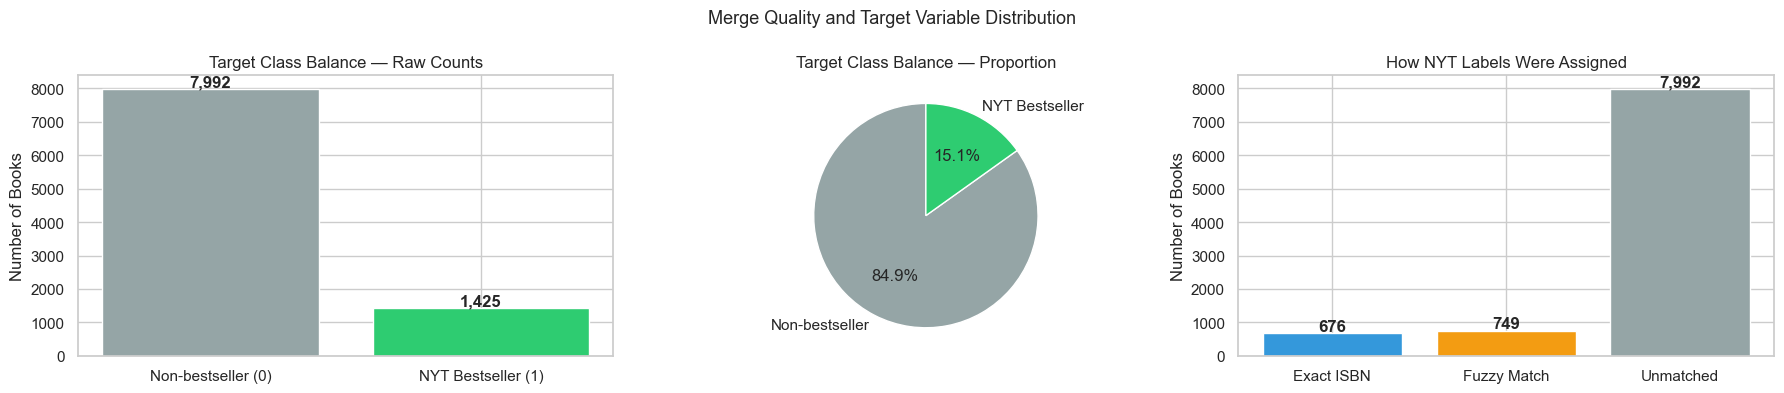

=== Merge audit ===
Rows in final merged dataset after publication-year filter: 9,417
Unique GoodBooks IDs: 9,417
Rows dropped with pub_year < 1931: 583

Match method breakdown:
match_method
exact_isbn             676
fuzzy_title_author     749
unmatched             7992
Name: count, dtype: int64

Total positives from exact ISBN: 676
Total positives from fuzzy:      749

Class ratio: 7,992 : 1,425 = 5.6:1


In [86]:
# ── 6.1 Merge audit and class balance ───────────────────────────────────────
assert merged['gb_id'].is_unique

counts = merged['nyt_bestseller'].value_counts().reindex([0, 1], fill_value=0)
match_counts = merged['match_method'].value_counts().reindex(
    ['exact_isbn', 'fuzzy_title_author', 'unmatched'], fill_value=0
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Target count plot
axes[0].bar(
    ['Non-bestseller (0)', 'NYT Bestseller (1)'],
    counts.values,
    color=[COLORS['non_bestseller'], COLORS['bestseller']]
)
axes[0].set_title('Target Class Balance — Raw Counts')
axes[0].set_ylabel('Number of Books')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.max() * 0.01, 5), f'{v:,}', ha='center', fontweight='bold')

# Target proportion pie chart
axes[1].pie(
    counts.values,
    labels=['Non-bestseller', 'NYT Bestseller'],
    colors=[COLORS['non_bestseller'], COLORS['bestseller']],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Target Class Balance — Proportion')

# Match method breakdown
bar_colors = [COLORS['exact'], COLORS['fuzzy'], COLORS['non_bestseller']]
axes[2].bar(
    ['Exact ISBN', 'Fuzzy Match', 'Unmatched'],
    match_counts.values,
    color=bar_colors
)
axes[2].set_title('How NYT Labels Were Assigned')
axes[2].set_ylabel('Number of Books')
for i, v in enumerate(match_counts.values):
    axes[2].text(i, v + max(match_counts.max() * 0.01, 5), f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Merge Quality and Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('eda_01_merge_audit_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Merge audit ===')
print(f'Rows in final merged dataset after publication-year filter: {len(merged):,}')
print(f'Unique GoodBooks IDs: {merged["gb_id"].nunique():,}')
if 'rows_dropped_pre_1931' in dir():
    print(f'Rows dropped with pub_year < 1931: {rows_dropped_pre_1931:,}')
print('\nMatch method breakdown:')
print(match_counts)
print(f'\nTotal positives from exact ISBN: {(merged["match_method"]=="exact_isbn").sum():,}')
print(f'Total positives from fuzzy:      {(merged["match_method"]=="fuzzy_title_author").sum():,}')
if counts.loc[1] > 0:
    print(f'\nClass ratio: {counts.loc[0]:,} : {counts.loc[1]:,} = {counts.loc[0]/counts.loc[1]:.1f}:1')
else:
    print('\nNo positive labels found — check the merge.')


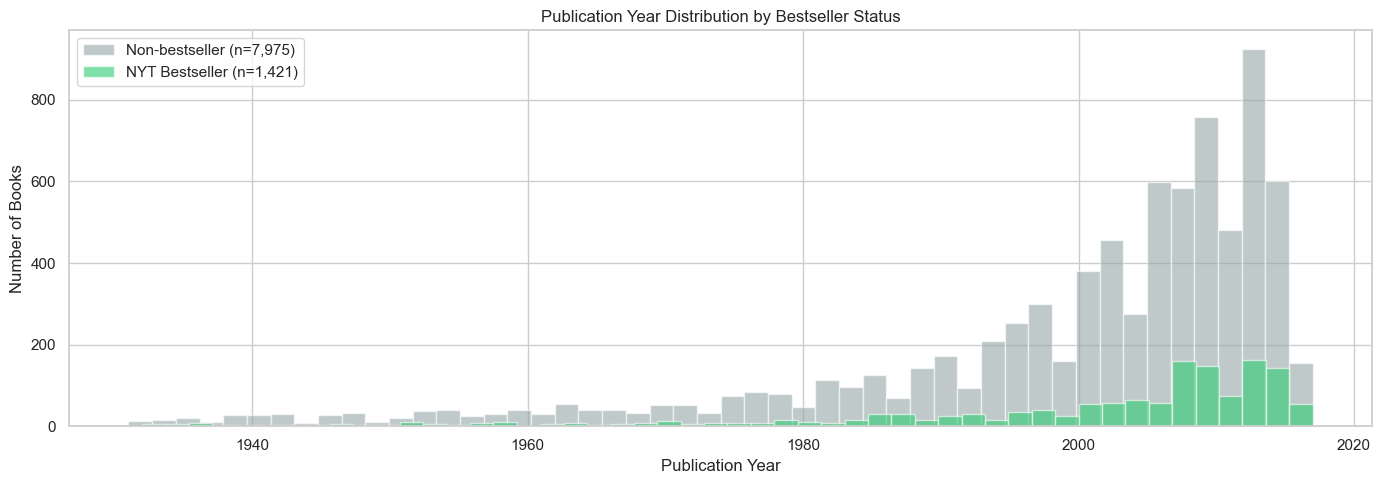

In [87]:
# ── 6.2 Publication year distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Plot separately for bestsellers and non-bestsellers.
for label, color, name in [
    (0, COLORS['non_bestseller'], 'Non-bestseller'),
    (1, COLORS['bestseller'], 'NYT Bestseller')
]:
    subset = merged[
        (merged['nyt_bestseller'] == label) &
        (merged['pub_year'] >= 1900) &
        (merged['pub_year'] <= 2026)
    ]
    ax.hist(
        subset['pub_year'].dropna(),
        bins=50,
        alpha=0.6,
        color=color,
        label=f'{name} (n={len(subset):,})'
    )

ax.set_title('Publication Year Distribution by Bestseller Status')
ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Books')
ax.legend()
plt.tight_layout()
plt.savefig('eda_02_publication_year.png', dpi=150, bbox_inches='tight')
plt.show()

              mean  count
pub_year                 
2005      0.098160    326
2006      0.157459    362
2007      0.220386    363
2008      0.211488    383
2009      0.164352    432
2010      0.162791    473
2011      0.134892    556
2012      0.142606    568
2013      0.156371    518
2014      0.176201    437
2015      0.212418    306
2016      0.257576    198
2017      0.272727     11


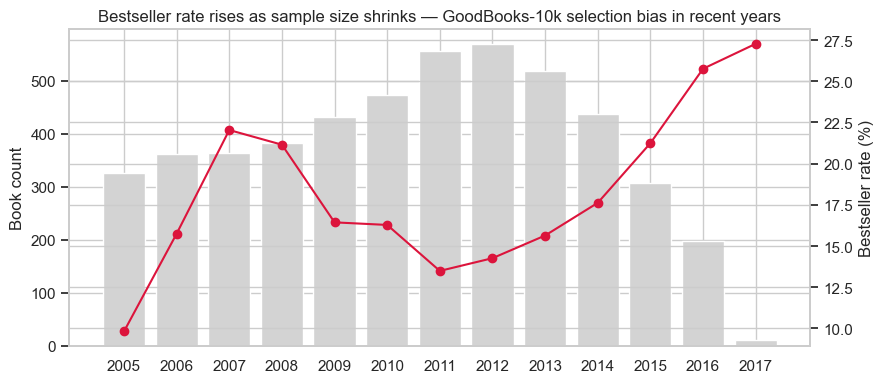

In [97]:
# ── 6.2b Bestseller rate by year, 2005–2017 (censoring check) ────────────
recent = merged[merged['pub_year'] >= 2005]
year_stats = recent.groupby('pub_year')['nyt_bestseller'].agg(['mean', 'count'])
print(year_stats)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(year_stats.index.astype(str), year_stats['count'], color='lightgray', label='n books')
ax2 = ax1.twinx()
ax2.plot(year_stats.index.astype(str), year_stats['mean']*100, color='crimson', marker='o', label='bestseller rate %')
ax1.set_ylabel('Book count')
ax2.set_ylabel('Bestseller rate (%)')
plt.title('Bestseller rate rises as sample size shrinks — GoodBooks-10k selection bias in recent years')
plt.tight_layout()
plt.savefig('eda_10_recent_year_censoring.png', dpi=150, bbox_inches='tight')
plt.show()

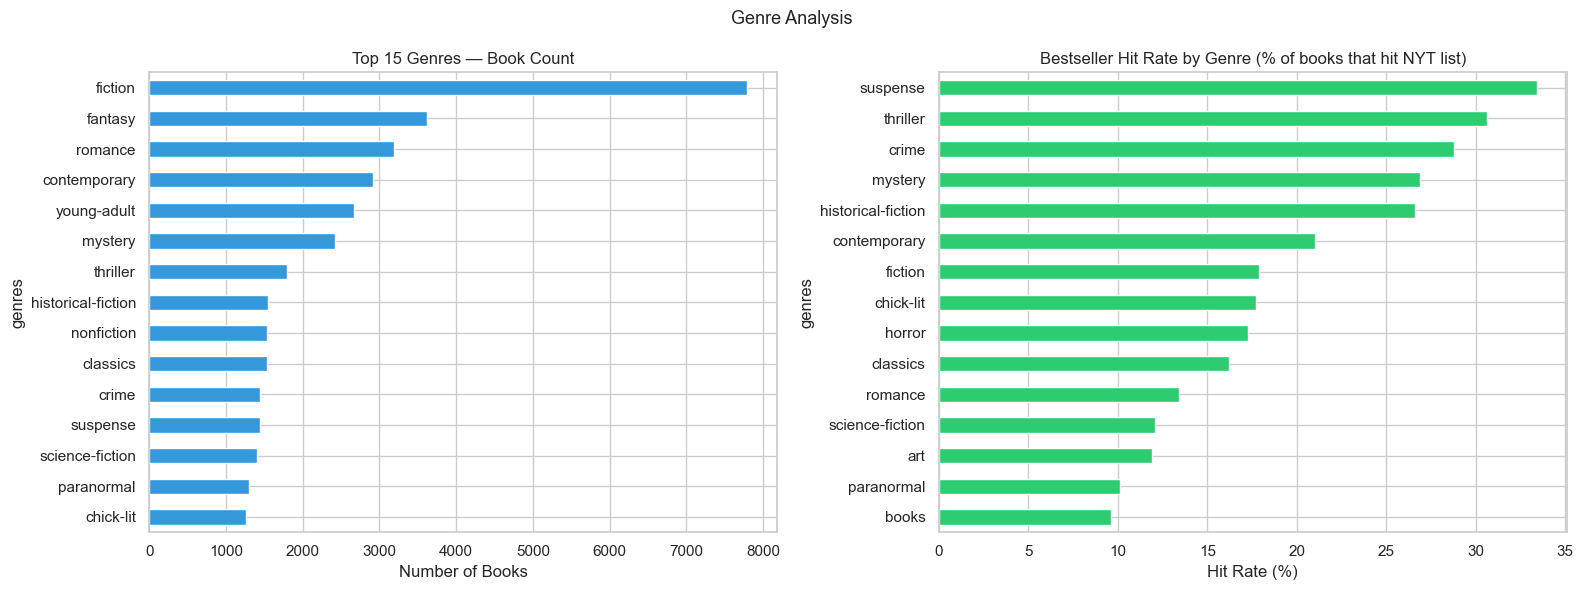


Top 10 genres by bestseller hit rate:
                    bestsellers  total_books  hit_rate
genres                                                
suspense                    482         1444      33.4
thriller                    550         1800      30.6
crime                       417         1447      28.8
mystery                     649         2417      26.9
historical-fiction          414         1555      26.6
contemporary                613         2918      21.0
fiction                    1393         7789      17.9
chick-lit                   224         1266      17.7
horror                      143          826      17.3
classics                    248         1531      16.2


In [88]:
# ── 6.3 Genre analysis ──────────────────────────────────────────────────────
# Explode genres list so each genre tag gets its own row
genre_exploded = merged[['nyt_bestseller', 'genres']].copy()
genre_exploded = genre_exploded.explode('genres')
genre_exploded = genre_exploded[genre_exploded['genres'].notna()]
genre_exploded = genre_exploded[genre_exploded['genres'] != '']

# Top 15 genres overall
top_genres = genre_exploded['genres'].value_counts().head(15)

# Bestseller rate per genre
genre_hit_rate = (
    genre_exploded.groupby('genres')['nyt_bestseller']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'bestsellers', 'count': 'total_books'})
)
genre_hit_rate['hit_rate'] = (genre_hit_rate['bestsellers'] / genre_hit_rate['total_books'] * 100).round(1)
genre_hit_rate = genre_hit_rate[genre_hit_rate['total_books'] >= 50]  # min 50 books
genre_hit_rate = genre_hit_rate.sort_values('hit_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top genres by count
top_genres.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Top 15 Genres — Book Count')
axes[0].set_xlabel('Number of Books')
axes[0].invert_yaxis()

# Right: bestseller hit rate by genre
genre_hit_rate.head(15)['hit_rate'].plot(kind='barh', ax=axes[1], color=COLORS['bestseller'])
axes[1].set_title('Bestseller Hit Rate by Genre (% of books that hit NYT list)')
axes[1].set_xlabel('Hit Rate (%)')
axes[1].invert_yaxis()

plt.suptitle('Genre Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('eda_03_genres.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 genres by bestseller hit rate:')
print(genre_hit_rate.head(10))

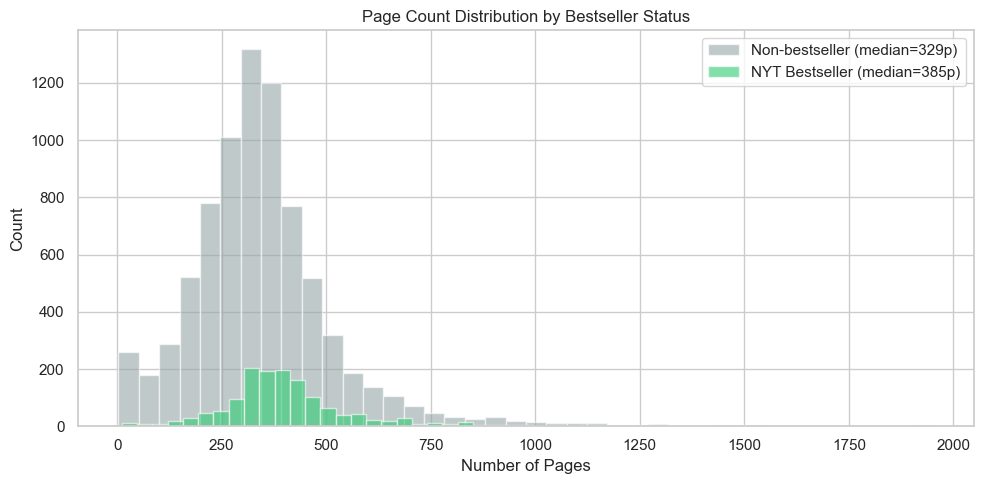

Page count by bestseller status:
                 count   mean    std   min    25%    50%    75%     max
nyt_bestseller                                                         
0               7909.0  346.7  182.4   3.0  243.0  329.0  416.0  1952.0
1               1419.0  409.6  168.9  11.0  318.0  385.0  464.0  1472.0


In [89]:
# ── 6.4 Page count by bestseller status ─────────────────────────────────────
pages_data = merged[merged['pages'].notna() & (merged['pages'] > 0) & (merged['pages'] < 2000)]

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [
    (0, COLORS['non_bestseller'], 'Non-bestseller'),
    (1, COLORS['bestseller'], 'NYT Bestseller')
]:
    subset = pages_data[pages_data['nyt_bestseller'] == label]['pages']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (median={subset.median():.0f}p)')

ax.set_title('Page Count Distribution by Bestseller Status')
ax.set_xlabel('Number of Pages')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('eda_04_page_count.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical summary
print('Page count by bestseller status:')
print(pages_data.groupby('nyt_bestseller')['pages'].describe().round(1))

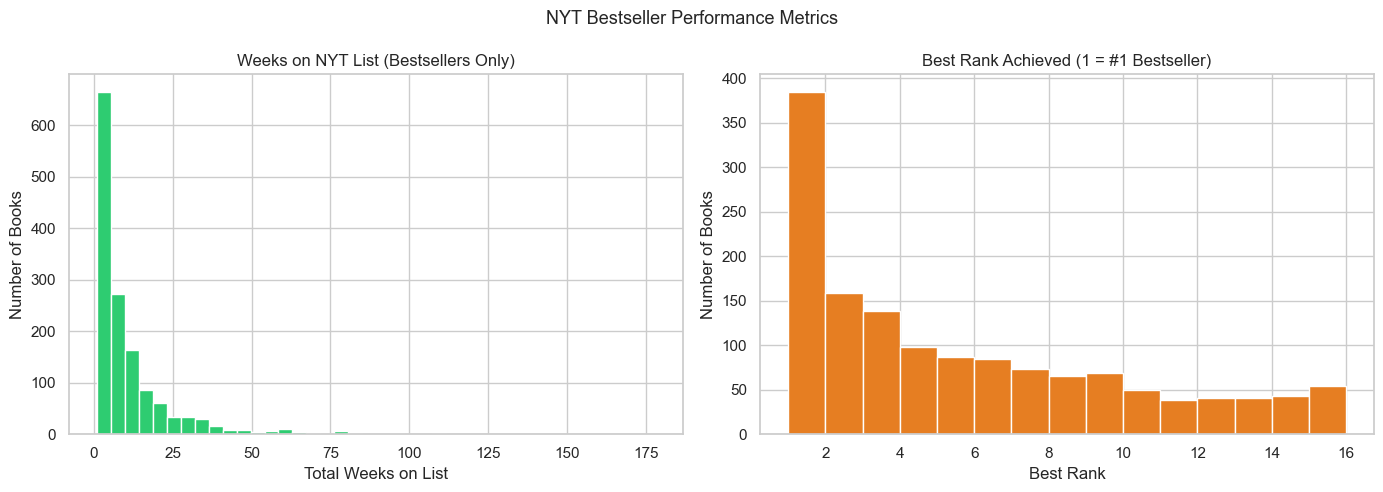

Weeks on list summary:
count    1425.0
mean       11.4
std        15.8
min         1.0
25%         3.0
50%         6.0
75%        13.0
max       178.0
Name: weeks_on_list, dtype: float64


In [90]:
# ── 6.5 Weeks on list distribution (bestsellers only) ───────────────────────
bestsellers_only = merged[merged['nyt_bestseller'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of weeks on list
axes[0].hist(bestsellers_only['weeks_on_list'], bins=40, color=COLORS['bestseller'], edgecolor='white')
axes[0].set_title('Weeks on NYT List (Bestsellers Only)')
axes[0].set_xlabel('Total Weeks on List')
axes[0].set_ylabel('Number of Books')

# Best rank distribution
axes[1].hist(
    bestsellers_only['best_rank_achieved'].dropna(),
    bins=15,
    color='#e67e22',
    edgecolor='white'
)
axes[1].set_title('Best Rank Achieved (1 = #1 Bestseller)')
axes[1].set_xlabel('Best Rank')
axes[1].set_ylabel('Number of Books')

plt.suptitle('NYT Bestseller Performance Metrics', fontsize=13)
plt.tight_layout()
plt.savefig('eda_05_bestseller_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Weeks on list summary:')
print(bestsellers_only['weeks_on_list'].describe().round(1))

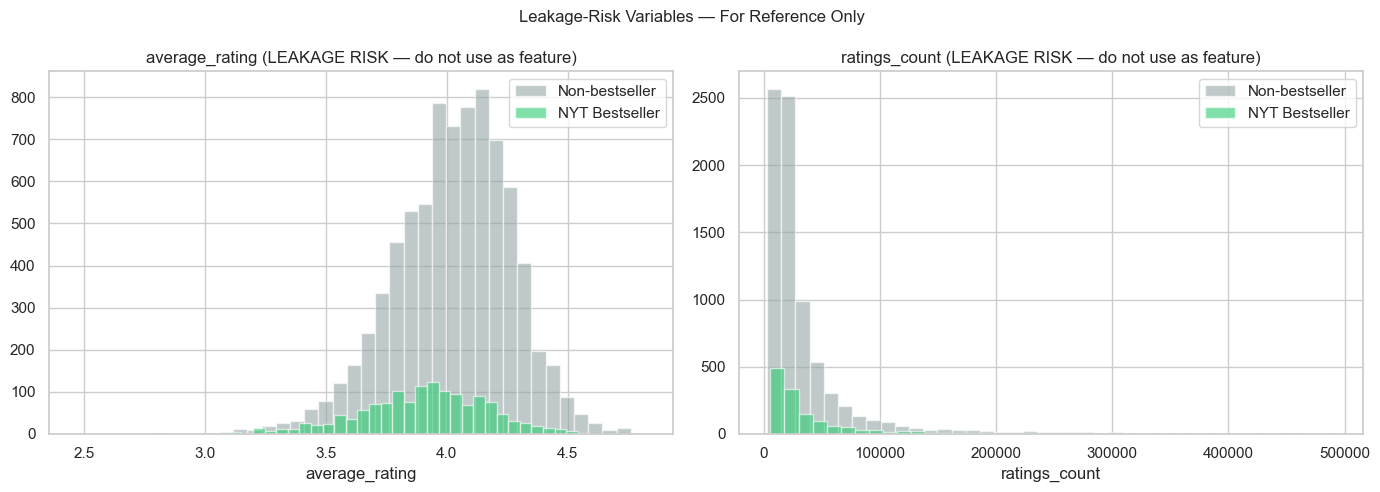

In [91]:
# ── 6.6 Leakage-risk variables vs bestseller status ─────────────────────────
# These are POST-publication outcomes — visualize to understand
# but remember NOT to use as model features.
leakage_present = [c for c in ['average_rating', 'ratings_count'] if c in merged.columns]

if leakage_present:
    fig, axes = plt.subplots(1, len(leakage_present), figsize=(14, 5))
    if len(leakage_present) == 1:
        axes = [axes]

    for ax, col in zip(axes, leakage_present):
        data_0 = merged[merged['nyt_bestseller'] == 0][col].dropna()
        data_1 = merged[merged['nyt_bestseller'] == 1][col].dropna()

        # Cap ratings_count at 99th percentile for readability
        if col == 'ratings_count':
            cap = data_0.quantile(0.99)
            data_0 = data_0[data_0 <= cap]
            data_1 = data_1[data_1 <= cap]

        ax.hist(data_0, bins=40, alpha=0.6, color=COLORS['non_bestseller'], label='Non-bestseller')
        ax.hist(data_1, bins=40, alpha=0.6, color=COLORS['bestseller'], label='NYT Bestseller')
        ax.set_title(f'{col} (LEAKAGE RISK — do not use as feature)')
        ax.set_xlabel(col)
        ax.legend()

    plt.suptitle('Leakage-Risk Variables — For Reference Only', fontsize=12)
    plt.tight_layout()
    plt.savefig('eda_06_leakage_vars.png', dpi=150, bbox_inches='tight')
    plt.show()

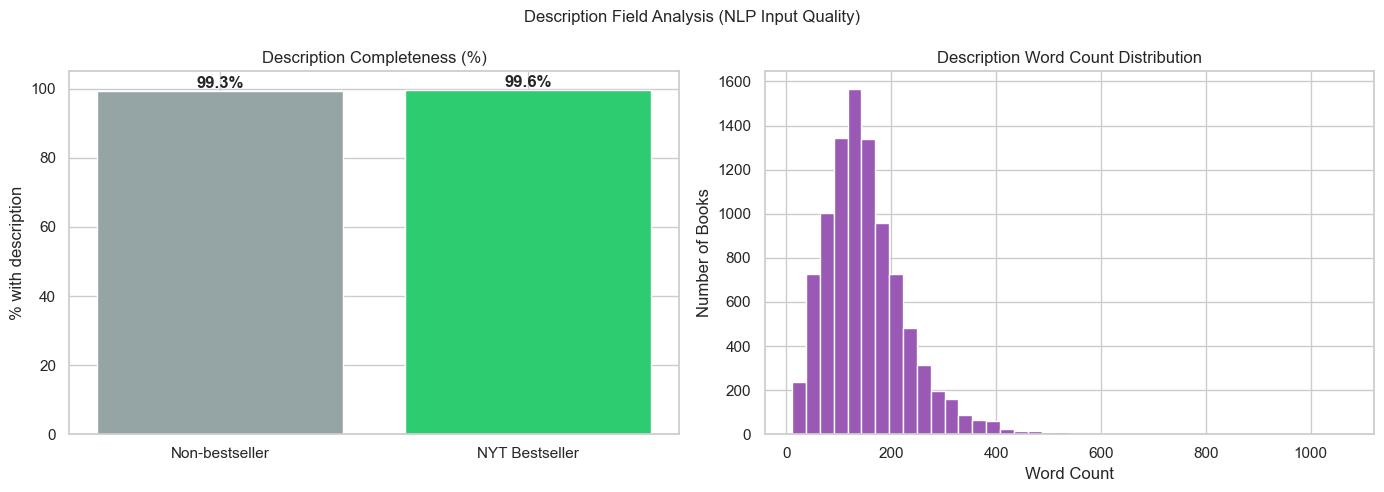

Description length summary:
count    9355.0
mean      152.2
std        80.1
min        11.0
25%        99.0
50%       140.0
75%       191.0
max      1068.0
Name: description_length, dtype: float64


In [92]:
# ── 6.7 Description completeness ───────────────────────────────────────────
merged['description_length'] = merged['description'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
merged['has_description'] = merged['description'].notna() & (merged['description_length'] > 10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Completeness by bestseller group
completeness = merged.groupby('nyt_bestseller')['has_description'].mean() * 100
axes[0].bar(
    ['Non-bestseller', 'NYT Bestseller'],
    completeness.values,
    color=[COLORS['non_bestseller'], COLORS['bestseller']]
)
axes[0].set_title('Description Completeness (%)')
axes[0].set_ylabel('% with description')
axes[0].set_ylim(0, 105)
for i, v in enumerate(completeness.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Description length distribution
desc_data = merged[merged['description_length'] > 10]
axes[1].hist(desc_data['description_length'], bins=40, color='#9b59b6', edgecolor='white')
axes[1].set_title('Description Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Books')

plt.suptitle('Description Field Analysis (NLP Input Quality)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_07_descriptions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Description length summary:')
print(desc_data['description_length'].describe().round(1))

In [98]:
# ── 6.7b Description length by bestseller status ──────────────────────────
desc_by_class = merged[merged['description'].notna()].copy()
desc_by_class['description_length'] = desc_by_class['description'].str.split().str.len()
print(desc_by_class.groupby('nyt_bestseller')['description_length'].describe().round(1))

                 count   mean   std  min    25%    50%    75%     max
nyt_bestseller                                                       
0               7959.0  148.5  79.6  1.0   97.0  137.0  185.0  1068.0
1               1421.0  170.5  82.3  1.0  111.0  158.0  222.0   537.0


In [93]:
# ── 6.8 Full EDA summary ────────────────────────────────────────────────────
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
print(f'Total books in merged dataset: {len(merged):,}')
print(f'Unique GoodBooks IDs: {merged["gb_id"].nunique():,}')
print(f'NYT Bestsellers: {merged["nyt_bestseller"].sum():,} ({merged["nyt_bestseller"].mean()*100:.1f}%)')
print(f'Non-bestsellers: {(merged["nyt_bestseller"]==0).sum():,}')
print()
print('Match method counts:')
print(merged['match_method'].value_counts())
print()
print('Feature completeness:')
for col in ['description', 'pages', 'pub_year', 'genres', 'isbn13_key']:
    if col in merged.columns:
        if col == 'genres':
            complete = merged['genres'].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
        else:
            complete = merged[col].notna().sum()
        print(f'  {col}: {complete:,} / {len(merged):,} ({complete/len(merged)*100:.1f}%)')
print()
print('Modeling reminder: exclude leakage-risk columns such as ratings_count, average_rating,')
print('work_text_reviews_count, and ratings_1–ratings_5 from pre-publication feature sets.')
print('Matching reminder: labels come from exact ISBN matching first, then fuzzy title-author matching for remaining unmatched rows.')
print(f'  Exact ISBN matches: {(merged["match_method"]=="exact_isbn").sum():,}')
print(f'  Fuzzy matches:      {(merged["match_method"]=="fuzzy_title_author").sum():,}')
print('Next steps: feature engineering → baseline model → full model → business-value evaluation')

EDA SUMMARY
Total books in merged dataset: 9,417
Unique GoodBooks IDs: 9,417
NYT Bestsellers: 1,425 (15.1%)
Non-bestsellers: 7,992

Match method counts:
match_method
unmatched             7992
fuzzy_title_author     749
exact_isbn             676
Name: count, dtype: int64

Feature completeness:
  description: 9,380 / 9,417 (99.6%)
  pages: 9,345 / 9,417 (99.2%)
  pub_year: 9,396 / 9,417 (99.8%)
  genres: 9,417 / 9,417 (100.0%)
  isbn13_key: 8,724 / 9,417 (92.6%)

Modeling reminder: exclude leakage-risk columns such as ratings_count, average_rating,
work_text_reviews_count, and ratings_1–ratings_5 from pre-publication feature sets.
Matching reminder: labels come from exact ISBN matching first, then fuzzy title-author matching for remaining unmatched rows.
  Exact ISBN matches: 676
  Fuzzy matches:      749
Next steps: feature engineering → baseline model → full model → business-value evaluation


CLASS BALANCE HEALTH CHECKS
Bestseller rate by decade:
 decade  total  bestsellers  hit_rate
   1930    107           21      19.6
   1940    155           20      12.9
   1950    210           38      18.1
   1960    272           30      11.0
   1970    400           56      14.0
   1980    704          112      15.9
   1990   1360          170      12.5
   2000   3121          464      14.9
   2010   3067          510      16.6

Top 15 genres by bestseller hit rate (min 50 books):
            genres  total  bestsellers  hit_rate
          suspense   1444          482      33.4
          thriller   1800          550      30.6
             crime   1447          417      28.8
           mystery   2417          649      26.9
historical-fiction   1555          414      26.6
      contemporary   2918          613      21.0
           fiction   7789         1393      17.9
         chick-lit   1266          224      17.7
            horror    826          143      17.3
          classics   

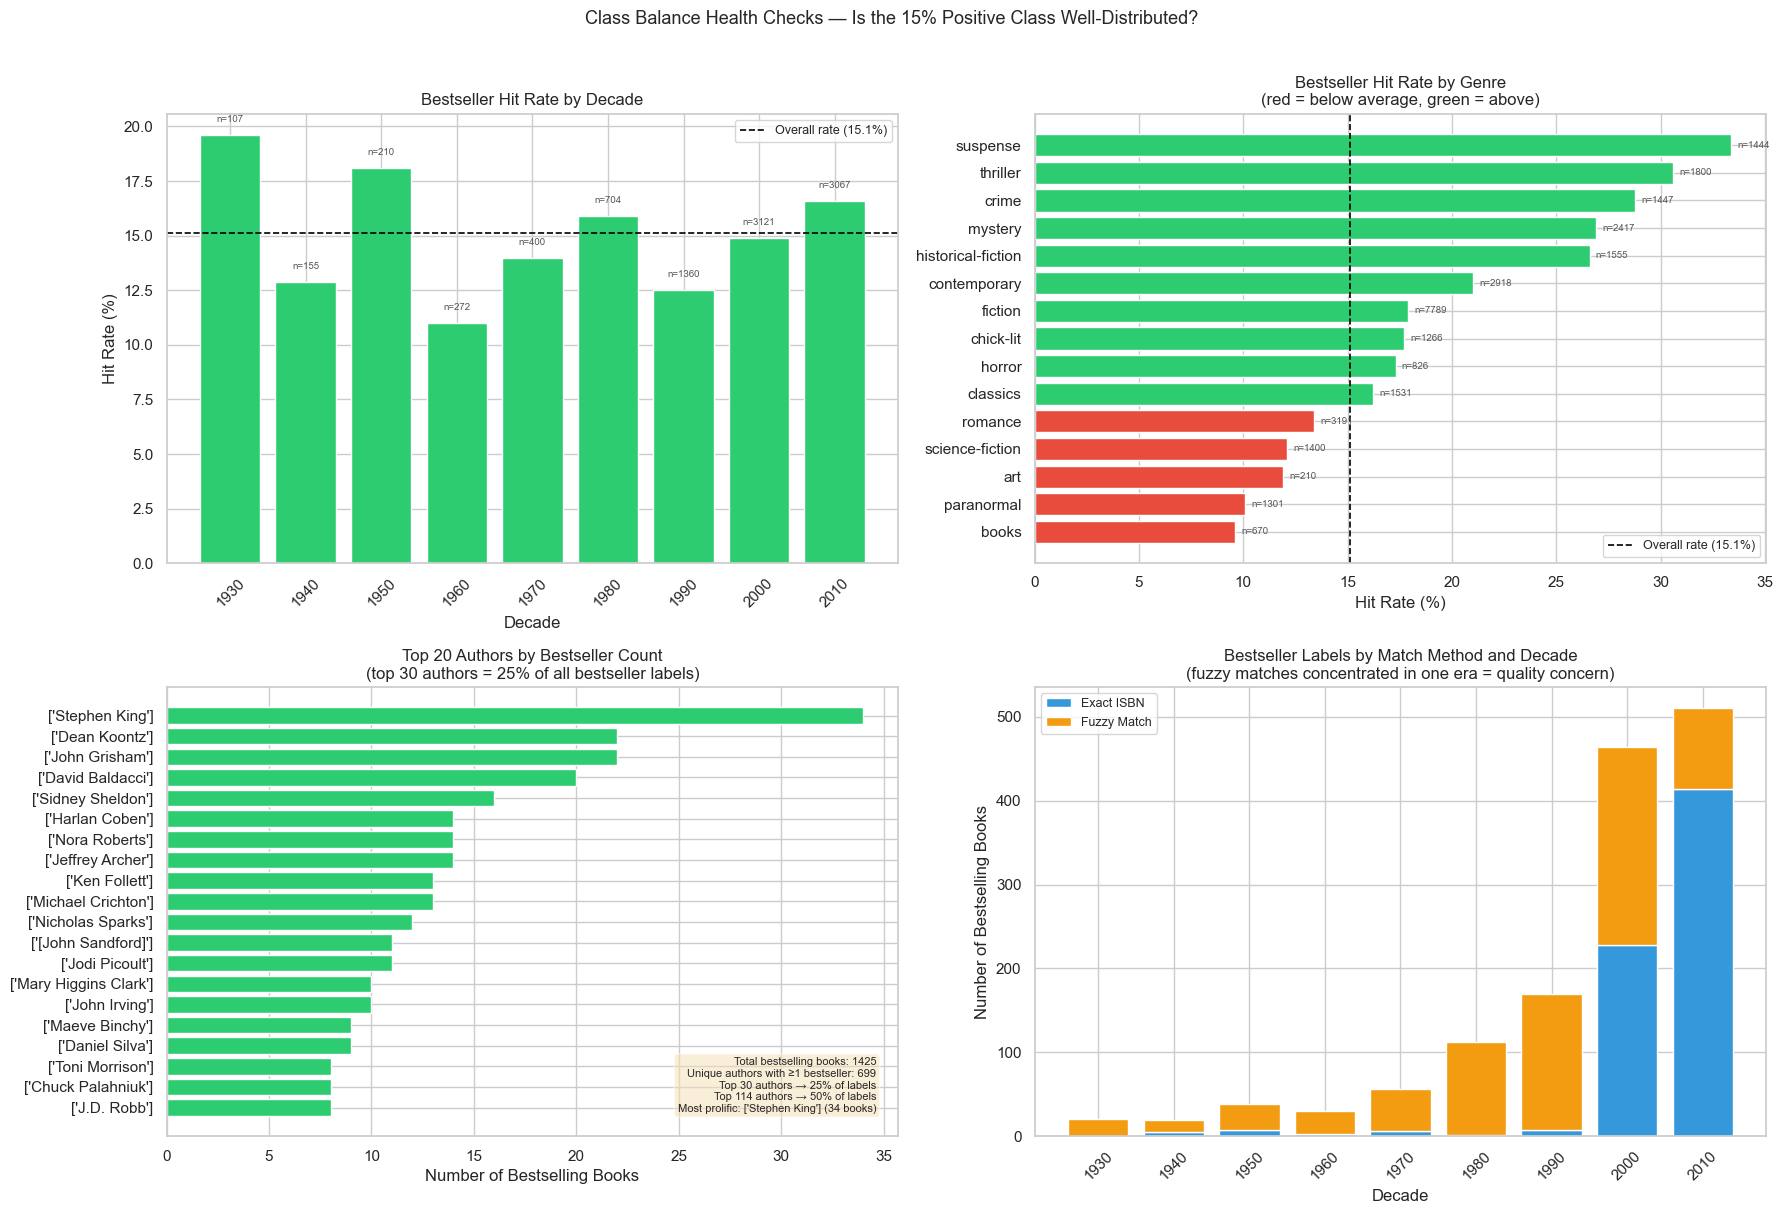

HEALTH CHECK VERDICT
Decade skew:      ✓  Hit rate reasonably stable across decades
  Min rate: 11.0%  Max rate: 19.6%
Author concentration: ✓  Labels spread across many authors
Fuzzy match share: ⚠️  >30% of positives came from fuzzy — review spot-check carefully
  Fuzzy positives: 749 (52.6% of all bestseller labels)


In [94]:
# ── 6.9 Class balance health checks ─────────────────────────────────────────
# These four checks validate that the 15% positive class is well-distributed
# across key dimensions — not clustered in one era, genre, or author.
# A skewed distribution here would suggest the model risks learning spurious
# signals (e.g. "old books = bestseller") rather than genuine success patterns.

print('=' * 60)
print('CLASS BALANCE HEALTH CHECKS')
print('=' * 60)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Check 1: Bestseller RATE by decade ──────────────────────────────────────
merged['decade'] = (merged['pub_year'] // 10 * 10).astype('Int64')

decade_stats = (
    merged[merged['decade'].between(1930, 2020)]
    .groupby('decade')['nyt_bestseller']
    .agg(total='count', bestsellers='sum')
    .assign(hit_rate=lambda x: (x['bestsellers'] / x['total'] * 100).round(1))
    .reset_index()
)

ax = axes[0, 0]
bars = ax.bar(
    decade_stats['decade'].astype(str),
    decade_stats['hit_rate'],
    color=[COLORS['bestseller'] if r >= 10 else '#e74c3c'
           for r in decade_stats['hit_rate']],
    edgecolor='white'
)
ax.axhline(merged['nyt_bestseller'].mean() * 100, color='black',
           linestyle='--', linewidth=1.2, label=f'Overall rate ({merged["nyt_bestseller"].mean()*100:.1f}%)')
ax.set_title('Bestseller Hit Rate by Decade', fontsize=12)
ax.set_xlabel('Decade')
ax.set_ylabel('Hit Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

# Annotate each bar with count
for bar, (_, row) in zip(bars, decade_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'n={int(row["total"])}',
            ha='center', va='bottom', fontsize=7, color='#555')

print('Bestseller rate by decade:')
print(decade_stats[['decade', 'total', 'bestsellers', 'hit_rate']].to_string(index=False))
print()

# ── Check 2: Bestseller RATE by genre ───────────────────────────────────────
genre_balance = (
    merged.explode('genres')
    .query("genres.notna() and genres != ''")
    .groupby('genres')['nyt_bestseller']
    .agg(total='count', bestsellers='sum')
    .assign(hit_rate=lambda x: (x['bestsellers'] / x['total'] * 100).round(1))
    .query('total >= 50')
    .sort_values('hit_rate', ascending=False)
    .head(15)
    .reset_index()
)

overall_rate = merged['nyt_bestseller'].mean() * 100

ax = axes[0, 1]
bar_colors = [COLORS['bestseller'] if r >= overall_rate else '#e74c3c'
              for r in genre_balance['hit_rate']]
hbars = ax.barh(genre_balance['genres'], genre_balance['hit_rate'],
                color=bar_colors, edgecolor='white')
ax.axvline(overall_rate, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall rate ({overall_rate:.1f}%)')
ax.set_title('Bestseller Hit Rate by Genre\n(red = below average, green = above)', fontsize=12)
ax.set_xlabel('Hit Rate (%)')
ax.invert_yaxis()
ax.legend(fontsize=9)

for bar, (_, row) in zip(hbars, genre_balance.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'n={int(row["total"])}', va='center', fontsize=7, color='#555')

print('Top 15 genres by bestseller hit rate (min 50 books):')
print(genre_balance[['genres', 'total', 'bestsellers', 'hit_rate']].to_string(index=False))
print()

# ── Check 3: Author concentration in positive class ─────────────────────────
# Are a small number of authors dominating the bestseller labels?
author_stats = (
    merged[merged['nyt_bestseller'] == 1]
    .groupby('authors')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='bestseller_count')
)

total_positives = merged['nyt_bestseller'].sum()
author_stats['cumulative_pct'] = (
    author_stats['bestseller_count'].cumsum() / total_positives * 100
).round(1)

# How many authors account for the top 25% / 50% of all bestsellers?
top_25_pct_authors = (author_stats['cumulative_pct'] <= 25).sum()
top_50_pct_authors = (author_stats['cumulative_pct'] <= 50).sum()

ax = axes[1, 0]
top_n = 20
top_authors = author_stats.head(top_n)
ax.barh(top_authors['authors'], top_authors['bestseller_count'],
        color=COLORS['bestseller'], edgecolor='white')
ax.set_title(f'Top {top_n} Authors by Bestseller Count\n'
             f'(top {top_25_pct_authors} authors = 25% of all bestseller labels)', fontsize=12)
ax.set_xlabel('Number of Bestselling Books')
ax.invert_yaxis()

# Lorenz-style concentration summary as text box
concentration_text = (
    f'Total bestselling books: {total_positives}\n'
    f'Unique authors with ≥1 bestseller: {len(author_stats)}\n'
    f'Top {top_25_pct_authors} authors → 25% of labels\n'
    f'Top {top_50_pct_authors} authors → 50% of labels\n'
    f'Most prolific: {author_stats.iloc[0]["authors"]} '
    f'({int(author_stats.iloc[0]["bestseller_count"])} books)'
)
ax.text(0.97, 0.05, concentration_text,
        transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

print('Author concentration in positive class:')
print(f'  Total bestselling books: {total_positives}')
print(f'  Unique authors with ≥1 bestseller: {len(author_stats)}')
print(f'  Top {top_25_pct_authors} authors account for 25% of all bestseller labels')
print(f'  Top {top_50_pct_authors} authors account for 50% of all bestseller labels')
print(f'  Top 10 most prolific bestselling authors:')
print(author_stats.head(10)[['authors', 'bestseller_count', 'cumulative_pct']].to_string(index=False))
print()

# ── Check 4: Match method vs label distribution ──────────────────────────────
# Do fuzzy-matched positives look different from ISBN-matched positives?
# Check by decade and by whether they have descriptions.
ax = axes[1, 1]

method_decade = (
    merged[merged['nyt_bestseller'] == 1]
    .assign(decade=lambda x: (x['pub_year'] // 10 * 10).astype('Int64'))
    .query('decade.between(1930, 2020)')
    .groupby(['decade', 'match_method'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Only plot columns that actually exist
method_cols = [c for c in ['exact_isbn', 'fuzzy_title_author'] if c in method_decade.columns]
method_colors = [COLORS['exact'], COLORS['fuzzy']][:len(method_cols)]
method_labels = ['Exact ISBN', 'Fuzzy Match'][:len(method_cols)]

bottom = np.zeros(len(method_decade))
for col, color, label in zip(method_cols, method_colors, method_labels):
    ax.bar(method_decade['decade'].astype(str),
           method_decade[col],
           bottom=bottom,
           color=color,
           label=label,
           edgecolor='white')
    bottom += method_decade[col].values

ax.set_title('Bestseller Labels by Match Method and Decade\n'
             '(fuzzy matches concentrated in one era = quality concern)', fontsize=12)
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Bestselling Books')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

# Compute fuzzy share per decade for the print summary
if 'fuzzy_title_author' in method_decade.columns:
    method_decade['fuzzy_share'] = (
        method_decade['fuzzy_title_author'] /
        method_decade[method_cols].sum(axis=1).replace(0, np.nan) * 100
    ).round(1)
    print('Match method breakdown by decade (among bestsellers):')
    print(method_decade[['decade'] + method_cols + (['fuzzy_share'] if 'fuzzy_share' in method_decade.columns else [])].to_string(index=False))
else:
    print('No fuzzy matches found — all labels came from exact ISBN matching.')
print()

plt.suptitle('Class Balance Health Checks — Is the 15% Positive Class Well-Distributed?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_09_class_balance_health.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overall verdict ──────────────────────────────────────────────────────────
print('=' * 60)
print('HEALTH CHECK VERDICT')
print('=' * 60)

# Decade skew flag
decade_rates = decade_stats['hit_rate']
decade_skew_flag = decade_rates.max() > 3 * decade_rates.min()
print(f'Decade skew:      {"⚠️  MAX rate is >3x MIN rate — consider decade as a control feature" if decade_skew_flag else "✓  Hit rate reasonably stable across decades"}')
print(f'  Min rate: {decade_rates.min():.1f}%  Max rate: {decade_rates.max():.1f}%')

# Author concentration flag
concentration_flag = top_25_pct_authors <= 5
print(f'Author concentration: {"⚠️  Top 5 authors = 25% of labels — model may learn author identity" if concentration_flag else "✓  Labels spread across many authors"}')

# Match method flag (only if fuzzy matches exist)
if 'fuzzy_title_author' in merged['match_method'].values:
    fuzzy_positives = (merged['match_method'] == 'fuzzy_title_author').sum()
    fuzzy_share = fuzzy_positives / total_positives * 100
    fuzzy_flag = fuzzy_share > 30
    print(f'Fuzzy match share: {"⚠️  >30% of positives came from fuzzy — review spot-check carefully" if fuzzy_flag else "✓  Fuzzy matches are a minority of positives"}')
    print(f'  Fuzzy positives: {fuzzy_positives} ({fuzzy_share:.1f}% of all bestseller labels)')
else:
    print('Fuzzy match share: ✓  All labels from exact ISBN (highest quality)')

In [96]:
# ── 6.10 Series membership vs bestseller rate ─────────────────────────────
merged['is_series'] = merged['title'].str.contains(r'#\d+', regex=True, na=False)

series_rate = merged.groupby('is_series')['nyt_bestseller'].agg(['mean', 'count'])
print(series_rate)

               mean  count
is_series                 
False      0.203759   5055
True       0.090555   4362


---
## Key Insights from EDA

**Label quality**
- Class balance: 15.1% positive, 5.6:1 negative:positive ratio → use `class_weight='balanced'`
  or equivalent in every baseline and downstream model.

**Cutoff-year choice (→ notebook 01)**
- Bestseller rate is *not* flat by year: it drifts from ~10–16% in 2005–2013 up to 21–27% in
  2015–2017, while the sample size shrinks (306 → 198 → 11 books). This is GoodBooks-10k
  selection bias, not a real trend — avoid a cutoff late enough to pull 2016–2017 into the test
  set.
- Decade-level hit rate is otherwise stable (11.0%–19.6% across 1930s–2010s), so no major
  temporal confound outside the recent-year tail.

**Strongest feature signal found so far: genre**
- Suspense/thriller/crime/mystery/historical-fiction genres run 27–33% bestseller rate — roughly
  2x the base rate. Romance, sci-fi, and paranormal sit below base rate (10–13%). Genre one-hot
  encoding looks like it will carry real signal.

**Series membership — counterintuitive, worth a closer look**
- Standalone titles bestseller at 20.4%, series entries at only 9.1% — a 2x gap in the opposite
  direction from what might be assumed. Worth including `is_series` as a feature.

**Weaker but real signals**
- Page count: bestsellers average ~410 pages vs ~347 for non-bestsellers (some separation, but
  wide overlap — std ~170-180 either way).
- Description length: bestsellers average ~170 words vs ~148 (modest signal, consistent with the
  `description_length` feature already planned).

**Not a concern**
- Author concentration is healthy: top 30 authors account for only 25% of positive labels, top
  114 for 50% — labels aren't dominated by a handful of prolific authors, so author-identity
  overfitting risk looks low (though `author_prior_nyt_count` still needs the temporal-only
  restriction already noted in `02`).

**Modeling plan**: genre and series-membership look like the two strongest
pre-existing signals going into `02_feature_engineering.ipynb`; page count and description
length are secondary. None of this changes the modeling plan structurally, but it justifies genre
and series as key features.

---
## What to do next

Next steps include:

1. **Feature engineering** — build structured features (is_series, has_subtitle, decade_published, genre_primary, genre_count) and author-history features (author_prior_nyt_count, author_debut, etc.) using the merged dataframe.

2. **NLP pipeline** — extract description_length, description_sentiment (VADER), and eventually description_embedding (sentence-transformers).

3. **Baseline model** — logistic regression on structured features only, to establish a benchmark AUC-ROC before adding NLP.

4. **Address class imbalance** — with ~5–15% positive class, we'll need class_weight='balanced' in sklearn or scale_pos_weight in XGBoost.